# EDA SISAIRE — Proyecto GeoVision-CLIP Cali

Análisis Exploratorio de Datos del SISAIRE leídos desde **Wasabi S3** (`bronze.sat/IDEAM/`),
alineado con los requisitos del proyecto y materializando el **silver layer** del medallion.

## Cobertura del notebook

- **Situación 1**: caracterización del ground truth, manifest del silver (MD5), EDA con visualizaciones.
- **Situación 2**: percentiles para pseudo-labels de tiles Sentinel-2 en GeoVision-CLIP.
- **Situación 3**:
  - factibilidad del LOO-CV espacial (solapamiento + correlaciones)
  - autocorrelación temporal (ACF/PACF) e insumo para ConvLSTM
  - estacionariedad (ADF + KPSS)
  - variograma experimental con 3 modelos teóricos (esférico, exponencial, gaussiano)
  - Moran I global + LISA local exploratorios

## Pre-procesamiento materializado

- Auditoría de calidad: unidades, dedup, gaps horarios, estación móvil
- Outliers físicos + filtro Hampel (mediana ± 4·MAD móvil) + detección de stuck values
- Imputación temporal lineal para gaps cortos (< 6h)
- Persistencia a Parquet particionado por contaminante con hash MD5

## Salidas

- `silver/sisaire_horaria.parquet` (particionado por contaminante)
- `silver/manifest_sisaire.json` (hashes, schema, umbrales)
- `eda_sisaire/` (figuras PNG, tablas CSV, reporte markdown)

## Setup

Dependencias y configuración del entorno gráfico.

In [1]:
%matplotlib inline
import os
import io
import re
import json
import hashlib
import warnings
from pathlib import Path
from itertools import combinations
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import boto3
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LogNorm

# Estadística temporal
from statsmodels.tsa.stattools import acf, pacf, adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Geoestadística
import skgstat as skg
import libpysal
from esda.moran import Moran, Moran_Local

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
})
print("Setup completo")

Setup completo


## Configuración del proyecto

Constantes del PDF + decisiones tomadas previamente (BBox extendido para incluir Yumbo,
fecha operacional Sentinel-5P, percentiles para pseudo-labels).

In [2]:
OUT_DIR    = "figuras"
SILVER_DIR = "silver"

# Bounding boxes del estudio
BBOX_ACTUAL    = (-76.60, 3.30, -76.40, 3.55)   # original PDF
BBOX_PROPUESTO = (-76.60, 3.28, -76.43, 3.60)   # extendido (incluye Yumbo)
S5P_INICIO     = pd.Timestamp("2018-04-30")     # operacional Sentinel-5P TROPOMI

# Resolución 2254/2017 — niveles máximos permisibles (µg/m³)
RES2254 = {
    "NO2": {"diario": 200, "anual": 60},
    "SO2": {"diario": 50,  "anual": 50},
    "O3":  {"horario": 100, "ocho_horas": 100},
}

# Percentiles para pseudo-labels (Situación 2)
PSEUDO_PERCENTILES = [25, 50, 75, 90, 99]

# Rangos físicos plausibles por contaminante (µg/m³)
RANGO_FISICO = {"NO2": (0, 500), "SO2": (0, 500), "O3": (0, 600)}

# Umbrales para el silver layer
MIN_DIAS_COBERTURA   = 90   # serie debe cubrir >= 90 días
MIN_OBS_VALIDAS      = 100  # serie debe tener >= 100 obs válidas tras limpieza
STUCK_VALUE_VENTANA  = 12   # >=12h con mismo valor consecutivo → stuck
HAMPEL_VENTANA_H     = 24
HAMPEL_N_SIGMAS      = 4.0
IMPUTACION_GAP_MAX_H = 6

SEED = 42
np.random.seed(SEED)

os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(SILVER_DIR, exist_ok=True)
print(f"Directorios: {OUT_DIR}/, {SILVER_DIR}/")

Directorios: eda_sisaire/, silver/


## Configuración Wasabi S3

Conexión al bucket `bronze.sat` (capa medallion bronze para datos satelitales y de calidad de aire).
Las credenciales se leen sin hardcoding.

In [3]:
# === Configuración del bucket ===
BUCKET_NAME  = "bronze.sat"
ENDPOINT_URL = "https://s3.us-west-1.wasabisys.com"
REGION_NAME  = "us-east-1"
PREFIX       = "IDEAM/"


def get_credentials():
    """Obtiene credenciales Wasabi: env vars > Colab Secrets > getpass interactivo."""
    ak = os.environ.get("WASABI_ACCESS_KEY")
    sk = os.environ.get("WASABI_SECRET_KEY")
    if ak and sk:
        return ak, sk, "env_vars"
    try:
        from google.colab import userdata
        ak = userdata.get("WASABI_ACCESS_KEY")
        sk = userdata.get("WASABI_SECRET_KEY")
        if ak and sk:
            return ak, sk, "colab_secrets"
    except Exception:
        pass
    import getpass
    print("Ingresá credenciales Wasabi (no se mostrarán):")
    return (getpass.getpass("Access Key: "),
            getpass.getpass("Secret Key: "),
            "getpass")


WASABI_ACCESS_KEY, WASABI_SECRET_KEY, fuente_creds = get_credentials()
print(f"Credenciales obtenidas vía: {fuente_creds}")

s3 = boto3.client(
    "s3",
    endpoint_url=ENDPOINT_URL,
    aws_access_key_id=WASABI_ACCESS_KEY,
    aws_secret_access_key=WASABI_SECRET_KEY,
    region_name=REGION_NAME,
)

# Sanity check: listar el primer objeto del prefix
try:
    test = s3.list_objects_v2(Bucket=BUCKET_NAME, Prefix=PREFIX, MaxKeys=1)
    n_keys = test.get("KeyCount", 0)
    print(f"[OK] conexión establecida | objetos accesibles bajo {PREFIX}: {n_keys > 0}")
    if n_keys:
        print(f"     ejemplo: {test['Contents'][0]['Key']}")
except Exception as e:
    print(f"[ERROR] conexión fallida: {e}")
    raise

Credenciales obtenidas vía: env_vars


[OK] conexión establecida | objetos accesibles bajo IDEAM/: True
     ejemplo: IDEAM/


## 1. Carga unificada desde Wasabi

Lee todos los CSVs bajo `IDEAM/{O3|NO2|SO2}/{cod_municipio}_{poll}.csv`, parsea nombres,
y unifica en un único DataFrame con las mismas columnas que el resto del EDA espera.

La columna `s3_key` se preserva como **trazabilidad bronze**: cada fila sabe de qué archivo S3 viene,
útil cuando armes el pipeline DLT silver.

In [4]:
def listar_archivos_csv(prefix=PREFIX):
    """Lista todos los .csv bajo el prefix, paginado nativamente."""
    paginator = s3.get_paginator("list_objects_v2")
    keys = []
    for page in paginator.paginate(Bucket=BUCKET_NAME, Prefix=prefix):
        for obj in page.get("Contents", []):
            if obj["Key"].endswith(".csv"):
                keys.append(obj["Key"])
    return keys


def parse_nombre(key):
    """Extrae (codigo_municipio, contaminante) del path IDEAM/{poll}/{cod}_{poll}.csv."""
    m = re.match(r"IDEAM/(O3|NO2|SO2)/(\d+)_(O3|NO2|SO2)\.csv$", key)
    if not m:
        return None, None
    contaminante, codigo_mun, _ = m.groups()
    return codigo_mun, contaminante


def leer_csv_s3(key, sep=";"):
    obj = s3.get_object(Bucket=BUCKET_NAME, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()), sep=sep)


def cargar_sisaire_desde_wasabi(prefix=PREFIX):
    """Lee todos los CSVs SISAIRE de Wasabi y devuelve un DataFrame unificado
    compatible con el resto del EDA."""
    frames = []
    keys = listar_archivos_csv(prefix)
    print(f"Encontrados {len(keys)} archivos bajo {prefix}\n")
    for key in keys:
        codigo_mun, poll = parse_nombre(key)
        if not codigo_mun:
            print(f"  [skip - no parseable] {key}")
            continue
        try:
            df_part = leer_csv_s3(key)
        except Exception as e:
            print(f"  [error - lectura] {key}: {e}")
            continue
        df_part["municipio_dane"] = codigo_mun
        df_part["contaminante"]   = poll
        df_part["s3_key"]         = key
        frames.append(df_part)
        print(f"  [ok] {key}  ({len(df_part):,d} filas)")
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


df_raw = cargar_sisaire_desde_wasabi()
print(f"\nFilas totales (crudas): {len(df_raw):,d}")
print(f"Columnas: {list(df_raw.columns)}")

Encontrados 8 archivos bajo IDEAM/



  [ok] IDEAM/NO2/76520_NO2.csv  (7,250 filas)
  [ok] IDEAM/NO2/76892_NO2.csv  (6,246 filas)


  [ok] IDEAM/O3/76001_O3.csv  (44,007 filas)


  [ok] IDEAM/O3/76520_O3.csv  (39,525 filas)


  [ok] IDEAM/O3/76892_O3.csv  (16,091 filas)


  [ok] IDEAM/SO2/76001_SO2.csv  (28,912 filas)
  [ok] IDEAM/SO2/76520_SO2.csv  (10,536 filas)


  [ok] IDEAM/SO2/76892_SO2.csv  (12,035 filas)

Filas totales (crudas): 164,602
Columnas: ['estacion_id', 'nombre_est', 'nombre_fgda', 'msfl_code', 'med_concentracion_estandar', 'med_fecha_inicio', 'med_fecha_final', 'latitud', 'longitud', 'altitud', 'sigla_unidad', 'duraci_n', 'municipio', 'tipo_estacion', 'municipio_dane', 'contaminante', 's3_key']


## 2. Normalización

Renombrado de columnas a nombres cortos consistentes, parseo de tipos numéricos/temporales,
y banderas pre-calculadas (`in_bbox_actual`, `in_bbox_propuesto`, `post_s5p`).

In [5]:
def normalizar(df_raw):
    df = df_raw.rename(columns={
        "nombre_est": "estacion",
        "nombre_fgda": "autoridad",
        "med_fecha_inicio": "fecha",
        "med_concentracion_estandar": "valor",
        "sigla_unidad": "unidad",
    }).copy()
    df["fecha"]    = pd.to_datetime(df["fecha"], errors="coerce")
    df["valor"]    = pd.to_numeric(df["valor"], errors="coerce")
    df["latitud"]  = pd.to_numeric(df["latitud"], errors="coerce")
    df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")
    if "altitud" in df.columns:
        df["altitud"] = pd.to_numeric(df["altitud"], errors="coerce")

    # Renombre canonico: ESTACION YUMBO -> ACOPI (corregimiento industrial real)
    # con coordenadas exactas 3 30'06.0"N 76 30'27.2"W
    df["estacion"] = df["estacion"].replace({"ESTACIÓN YUMBO": "ACOPI"})
    mask_acopi = df["estacion"] == "ACOPI"
    df.loc[mask_acopi, "latitud"]  =  3.501678
    df.loc[mask_acopi, "longitud"] = -76.507554

    df["in_bbox_actual"] = (
        df["latitud"].between(BBOX_ACTUAL[1], BBOX_ACTUAL[3])
        & df["longitud"].between(BBOX_ACTUAL[0], BBOX_ACTUAL[2])
    )
    df["in_bbox_propuesto"] = (
        df["latitud"].between(BBOX_PROPUESTO[1], BBOX_PROPUESTO[3])
        & df["longitud"].between(BBOX_PROPUESTO[0], BBOX_PROPUESTO[2])
    )
    df["post_s5p"] = df["fecha"] >= S5P_INICIO
    return df


df = normalizar(df_raw)
print(f"Mediciones totales:  {len(df):,d}")
print(f"Estaciones únicas:   {df['estacion'].nunique()}")
print(f"Autoridades:         {sorted(df['autoridad'].dropna().unique().tolist())}")
print(f"Contaminantes:       {sorted(df['contaminante'].unique().tolist())}")
print(f"Rango temporal:      {df['fecha'].min()} → {df['fecha'].max()}")
print(f"Mediciones post-S5P: {int(df['post_s5p'].sum()):,d} ({df['post_s5p'].mean()*100:.1f}%)")
print(f"\nEstaciones renombradas (ACOPI sustituye a ESTACION YUMBO):")
print(df.query("estacion == 'ACOPI'")[['estacion','latitud','longitud']].drop_duplicates().to_string(index=False))
df.head()


Mediciones totales:  164,602
Estaciones únicas:   12
Autoridades:         ['CVC', 'DAGMA']
Contaminantes:       ['NO2', 'O3', 'SO2']
Rango temporal:      2020-01-01 00:00:00 → 2024-12-31 23:00:00
Mediciones post-S5P: 164,602 (100.0%)

Estaciones renombradas (ACOPI sustituye a ESTACION YUMBO):
estacion  latitud   longitud
   ACOPI 3.501678 -76.507554


,estacion_id,estacion,autoridad,msfl_code,valor,fecha,med_fecha_final,latitud,longitud,altitud,unidad,duraci_n,municipio,tipo_estacion,municipio_dane,contaminante,s3_key,in_bbox_actual,in_bbox_propuesto,post_s5p
0,31817,MOVIL,CVC,NO2,5.95,2021-10-07 10:00:00,2021-10-07T11:00:00.000,3.510503,-76.308111,1050,ug/m3,60,Palmira,Fija,76520,NO2,IDEAM/NO2/76520_NO2.csv,False,False,True
1,31817,MOVIL,CVC,NO2,4.03,2021-10-07 11:00:00,2021-10-07T12:00:00.000,3.510503,-76.308111,1050,ug/m3,60,Palmira,Fija,76520,NO2,IDEAM/NO2/76520_NO2.csv,False,False,True
2,31817,MOVIL,CVC,NO2,4.36,2021-10-07 12:00:00,2021-10-07T13:00:00.000,3.510503,-76.308111,1050,ug/m3,60,Palmira,Fija,76520,NO2,IDEAM/NO2/76520_NO2.csv,False,False,True
3,31817,MOVIL,CVC,NO2,4.62,2021-10-07 13:00:00,2021-10-07T14:00:00.000,3.510503,-76.308111,1050,ug/m3,60,Palmira,Fija,76520,NO2,IDEAM/NO2/76520_NO2.csv,False,False,True
4,31817,MOVIL,CVC,NO2,5.01,2021-10-07 14:00:00,2021-10-07T15:00:00.000,3.510503,-76.308111,1050,ug/m3,60,Palmira,Fija,76520,NO2,IDEAM/NO2/76520_NO2.csv,False,False,True


## 3. Auditoría de calidad de datos

Verificaciones que las situaciones 2 y 3 dependen:

- **Consistencia de unidades** por estación-contaminante (LOO-CV exige misma escala).
- **Estación móvil**: si `MOVIL` (CVC) cambió de coordenadas, rompe el supuesto de Kriging estacionario.
- **Duplicados** en `(estación, contaminante, fecha)`: SISAIRE reprocesa series y deja duplicados.
- **Frecuencia horaria efectiva**: porcentaje de horas perdidas vs. esperadas.

In [6]:
# 3.1 Consistencia de unidades por serie
unidades_por_serie = (df.groupby(["estacion", "contaminante"])["unidad"]
                       .agg(["nunique", "first"])
                       .rename(columns={"nunique": "n_unidades", "first": "unidad"}))
print("[unidades] máximo de unidades distintas dentro de una serie:",
      int(unidades_por_serie["n_unidades"].max()))
print(unidades_por_serie["unidad"].value_counts().to_string())

# 3.2 Auditar estación MOVIL (CVC) — verificar si las coordenadas cambian en el tiempo
movil = (df.query("estacion == 'MOVIL'")
           [["fecha", "latitud", "longitud", "contaminante"]]
           .copy())
if len(movil):
    coords_unicas = movil[["latitud", "longitud"]].drop_duplicates()
    print(f"\n[MOVIL] coordenadas únicas registradas: {len(coords_unicas)}")
    print(coords_unicas.to_string(index=False))
    if len(coords_unicas) > 1:
        print("[MOVIL] CONCLUSIÓN: la estación cambia de posición → "
              "EXCLUIR del Kriging estacionario; usable solo para validación OOD.")
    else:
        print("[MOVIL] CONCLUSIÓN: posición única → tratar como estación fija.")
else:
    print("\n[MOVIL] sin registros en el dataset.")

# 3.3 Duplicados exactos en la clave (estación, contaminante, fecha)
dups_mask = df.duplicated(subset=["estacion", "contaminante", "fecha"], keep=False)
print(f"\n[duplicados] {int(dups_mask.sum()):,d} filas en clave duplicada "
      f"({dups_mask.mean()*100:.2f}% del total)")
if dups_mask.any():
    ej = (df[dups_mask]
            .sort_values(["estacion", "contaminante", "fecha"])
            .head(6)[["estacion", "contaminante", "fecha", "valor", "s3_key"]])
    print(ej.to_string(index=False))

# 3.4 Frecuencia horaria efectiva — % de horas perdidas vs. horas esperadas
def gap_analysis(df_serie):
    if df_serie.empty:
        return None
    f0, f1 = df_serie["fecha"].min(), df_serie["fecha"].max()
    horas_esperadas  = int((f1 - f0).total_seconds() // 3600) + 1
    horas_observadas = df_serie["fecha"].dt.floor("h").nunique()
    return {
        "horas_esperadas":  horas_esperadas,
        "horas_observadas": horas_observadas,
        "pct_perdido":      round((1 - horas_observadas / horas_esperadas) * 100, 2),
    }

gap_rows = []
for (est, poll), sub in df.dropna(subset=["fecha"]).groupby(["estacion", "contaminante"]):
    g = gap_analysis(sub)
    if g:
        gap_rows.append({"estacion": est, "contaminante": poll, **g})

gap_df = (pd.DataFrame(gap_rows)
            .sort_values("pct_perdido", ascending=False)
            .reset_index(drop=True))
gap_df.to_csv(f"{OUT_DIR}/tabla_gaps_horarios.csv", index=False)
print(f"\n[gaps horarios] series con > 30% horas perdidas: "
      f"{int((gap_df['pct_perdido']>30).sum())} de {len(gap_df)}")
print(gap_df.head(10).to_string(index=False))

[unidades] máximo de unidades distintas dentro de una serie: 1


unidad
ug/m3    21

[MOVIL] coordenadas únicas registradas: 1
 latitud   longitud
3.510503 -76.308111
[MOVIL] CONCLUSIÓN: posición única → tratar como estación fija.

[duplicados] 0 filas en clave duplicada (0.00% del total)



[gaps horarios] series con > 30% horas perdidas: 18 de 21
             estacion contaminante  horas_esperadas  horas_observadas  pct_perdido
              PALMIRA          NO2            23664              1080        95.44
                ACOPI          NO2            30336              6246        79.41
         CAÑAVERALEJO          SO2            21638              5053        76.65
                PANCE           O3            24744              5861        76.31
           BASE AÉREA          SO2            32316              7770        75.96
UNIVERSIDAD DEL VALLE           O3            25827              6350        75.41
             LA FLORA           O3            23699              5902        75.10
           BASE AÉREA           O3            29029              7310        74.82
           ERA OBRERO           O3            24696              6939        71.90
            COMPARTIR           O3            26304              7507        71.46


## 4. Resumen por estación

Tabla pivote (estación × contaminante) con cobertura, calidad y bandera BBox.
Es la base para todas las decisiones del LOO-CV.

In [7]:
def resumen_estaciones(df):
    g = df.groupby(["estacion", "autoridad", "contaminante",
                    "latitud", "longitud", "altitud", "unidad"], dropna=False)
    rows = []
    for (est, fgda, poll, lat, lon, alt, unit), sub in g:
        v = sub["valor"].dropna()
        rows.append({
            "estacion": est, "autoridad": fgda, "contaminante": poll,
            "lat": lat, "lon": lon, "alt": alt, "unidad": unit,
            "n_total": len(sub), "n_validos": len(v),
            "pct_missing": round((1 - len(v)/len(sub)) * 100, 2) if len(sub) else 0,
            "n_post_s5p": int(sub["post_s5p"].sum()),
            "fecha_min": sub["fecha"].min(), "fecha_max": sub["fecha"].max(),
            "dias_cobertura": (sub["fecha"].max() - sub["fecha"].min()).days,
            "media": round(v.mean(), 2) if len(v) else np.nan,
            "mediana": round(v.median(), 2) if len(v) else np.nan,
            "p90": round(v.quantile(0.90), 2) if len(v) else np.nan,
            "p99": round(v.quantile(0.99), 2) if len(v) else np.nan,
            "max": round(v.max(), 2) if len(v) else np.nan,
            "in_bbox_actual": bool(sub["in_bbox_actual"].iloc[0]),
            "in_bbox_propuesto": bool(sub["in_bbox_propuesto"].iloc[0]),
        })
    return pd.DataFrame(rows).sort_values(["contaminante", "n_post_s5p"],
                                           ascending=[True, False])

resumen = resumen_estaciones(df)
resumen.to_csv(f"{OUT_DIR}/tabla_estaciones.csv", index=False)
print(f"{len(resumen)} pares (estación × contaminante)")
resumen

21 pares (estación × contaminante)


,estacion,autoridad,contaminante,lat,lon,alt,unidad,n_total,n_validos,pct_missing,...,fecha_min,fecha_max,dias_cobertura,media,mediana,p90,p99,max,in_bbox_actual,in_bbox_propuesto
0,ACOPI,CVC,NO2,3.501678,-76.507554,950,ug/m3,6246,6246,0.0,...,2020-11-01 00:00:00,2024-04-17 23:00:00,1263,10.07,8.70,18.90,36.71,163.90,True,True
11,MOVIL,CVC,NO2,3.510503,-76.308111,1050,ug/m3,6170,6170,0.0,...,2021-10-07 10:00:00,2022-12-31 23:00:00,450,6.82,6.38,10.94,15.10,16.60,False,False
14,PALMIRA,CVC,NO2,3.537500,-76.300833,965,ug/m3,1080,1080,0.0,...,2022-01-01 00:00:00,2024-09-12 23:00:00,985,5.37,4.85,7.62,18.61,34.40,False,False
15,PALMIRA,CVC,O3,3.537500,-76.300833,965,ug/m3,24415,24415,0.0,...,2020-01-17 14:00:00,2024-12-04 23:00:00,1783,18.08,10.00,40.10,109.50,172.90,False,False
1,ACOPI,CVC,O3,3.501678,-76.507554,950,ug/m3,16091,16091,0.0,...,2020-07-01 01:00:00,2024-12-31 23:00:00,1644,19.71,12.00,45.30,111.82,194.90,True,True
12,MOVIL,CVC,O3,3.510503,-76.308111,1050,ug/m3,15110,15110,0.0,...,2020-07-01 00:00:00,2022-10-28 23:00:00,849,11.69,7.40,33.30,47.20,50.90,False,False
6,COMPARTIR,DAGMA,O3,3.428260,-76.466584,952,ug/m3,7507,7507,0.0,...,2020-01-01 00:00:00,2022-12-31 23:00:00,1095,12.14,8.51,33.34,69.48,81.70,True,True
3,BASE AÉREA,DAGMA,O3,3.457128,-76.502303,956,ug/m3,7310,7310,0.0,...,2020-01-21 15:00:00,2023-05-15 03:00:00,1209,6.08,2.28,19.74,47.62,58.27,True,True
7,ERA OBRERO,DAGMA,O3,3.457317,-76.506539,968,ug/m3,6939,6939,0.0,...,2020-01-01 00:00:00,2022-10-25 23:00:00,1028,8.97,4.77,23.23,64.60,79.89,True,True
20,UNIVERSIDAD DEL VALLE,DAGMA,O3,3.377911,-76.533811,985,ug/m3,6350,6350,0.0,...,2020-05-03 06:00:00,2023-04-14 08:00:00,1076,9.16,7.37,20.62,62.25,120.58,True,True


## 5. Pipeline de limpieza y materialización del silver layer

Convierte el `df` bronze-normalizado en `df_silver` listo para Sit. 2 y Sit. 3:

1. **Deduplica** `(estación, contaminante, fecha)` quedándose con el último valor (`keep='last'`).
2. **Resamplea** a frecuencia horaria estricta (`asfreq('h')`) — gaps quedan como `NaN` explícitos.
3. **Marca outliers físicos** (`flag_fisico`): valor fuera del rango plausible.
4. **Marca outliers estadísticos** (`flag_estadistico`) vía **filtro Hampel**:
   mediana ± 4·MAD móvil con ventana 24h. Hampel es robusto a colas pesadas — apropiado
   para contaminantes cuya distribución dista mucho de gaussiana.
5. **Marca stuck values** (`flag_stuck`): runs de ≥ 12 h con valor idéntico (sensor pegado).
6. **Imputa** gaps cortos (< 6 h) con interpolación temporal lineal sobre el valor limpio
   (sin outliers ni stuck). Gaps largos quedan como `NaN`.
7. **Filtra** series con `n_validos < 100` o `dias_cobertura < 90` para LOO-CV.
8. **Persiste** a Parquet particionado por `contaminante` con hash MD5 reproducible.

Las cuatro columnas de salida son `valor` (bruto), `valor_limpio` (sin outliers), `valor_imputado`
(versión final lista para modelar) y los tres flags. Esto preserva la trazabilidad — cualquier
decisión es reversible inspeccionando los flags.

In [8]:
def hampel_filter(serie, ventana=HAMPEL_VENTANA_H, n_sigmas=HAMPEL_N_SIGMAS):
    """Filtro Hampel: mediana ± n·MAD móvil. K=1.4826 da consistencia gaussiana."""
    K = 1.4826
    mediana = serie.rolling(window=ventana, center=True, min_periods=ventana // 3).median()
    mad     = (serie - mediana).abs().rolling(window=ventana, center=True,
                                              min_periods=ventana // 3).median()
    umbral_inf = mediana - n_sigmas * K * mad
    umbral_sup = mediana + n_sigmas * K * mad
    return ~serie.between(umbral_inf, umbral_sup, inclusive="both")


def detectar_stuck(serie, ventana=STUCK_VALUE_VENTANA):
    """Marca True donde el valor ha sido idéntico por >= ventana muestras consecutivas."""
    cambios = serie.diff().fillna(1).ne(0).astype(int)
    grupos  = cambios.cumsum()
    tam     = grupos.map(grupos.value_counts())
    return (tam >= ventana) & serie.notna()


def construir_silver(df_in, gap_max_h=IMPUTACION_GAP_MAX_H):
    """Construye el silver layer a partir del bronze normalizado.
    Devuelve (df_silver, log_limpieza)."""
    silver_parts = []
    flags_log = []
    columnas_meta = ["autoridad", "latitud", "longitud", "altitud", "unidad",
                     "municipio", "tipo_estacion", "municipio_dane", "s3_key"]

    for (est, poll), sub in df_in.dropna(subset=["fecha"]).groupby(["estacion", "contaminante"]):
        # 1. Dedup en clave
        n_dup_pre = len(sub)
        sub = (sub.sort_values("fecha")
                  .drop_duplicates(subset=["estacion", "contaminante", "fecha"], keep="last"))
        n_dup_caidos = n_dup_pre - len(sub)

        meta = sub.iloc[0]
        # 2. Resample a frecuencia horaria estricta
        sub = sub.set_index("fecha")
        rng = pd.date_range(sub.index.min().floor("h"), sub.index.max().ceil("h"), freq="h")
        sub = sub.reindex(rng).rename_axis("fecha").reset_index()
        sub["estacion"]     = est
        sub["contaminante"] = poll
        for col in columnas_meta:
            if col in df_in.columns:
                sub[col] = meta[col]

        # 3. Outliers físicos
        lo, hi = RANGO_FISICO[poll]
        sub["flag_fisico"] = (~sub["valor"].between(lo, hi)) & sub["valor"].notna()

        # 4. Outliers estadísticos (Hampel)
        sub["flag_estadistico"] = (hampel_filter(sub["valor"]).fillna(False)
                                   & sub["valor"].notna())

        # 5. Stuck values
        sub["flag_stuck"] = detectar_stuck(sub["valor"]).fillna(False)

        # 6. valor_limpio: NaN para flags activos
        mascara_invalida = sub[["flag_fisico", "flag_estadistico", "flag_stuck"]].any(axis=1)
        sub["valor_limpio"] = sub["valor"].where(~mascara_invalida)

        # 7. Imputación lineal en el tiempo (gap_max_h)
        s_imp = (sub.set_index("fecha")["valor_limpio"]
                    .interpolate(method="time", limit=gap_max_h, limit_area="inside")
                    .reset_index(drop=True))
        sub["valor_imputado"] = s_imp.values
        sub["fue_imputado"]   = sub["valor_limpio"].isna() & sub["valor_imputado"].notna()

        flags_log.append({
            "estacion": est, "contaminante": poll,
            "n_horario":          len(sub),
            "n_dedup_caidos":     n_dup_caidos,
            "n_validos_brutos":   int(sub["valor"].notna().sum()),
            "n_flag_fisico":      int(sub["flag_fisico"].sum()),
            "n_flag_estadistico": int(sub["flag_estadistico"].sum()),
            "n_flag_stuck":       int(sub["flag_stuck"].sum()),
            "n_imputados":        int(sub["fue_imputado"].sum()),
            "n_validos_finales":  int(sub["valor_imputado"].notna().sum()),
            "dias_cobertura":     int((sub["fecha"].max() - sub["fecha"].min()).days),
        })
        silver_parts.append(sub)

    silver = pd.concat(silver_parts, ignore_index=True)
    log = pd.DataFrame(flags_log)
    log["serie_aceptada"] = ((log["n_validos_finales"] >= MIN_OBS_VALIDAS)
                             & (log["dias_cobertura"]    >= MIN_DIAS_COBERTURA))
    return silver, log


df_silver, silver_log = construir_silver(df)
silver_log.to_csv(f"{OUT_DIR}/log_limpieza_silver.csv", index=False)

print("Resumen del log de limpieza:")
print(silver_log.to_string(index=False))
print(f"\nSeries aceptadas para LOO-CV: "
      f"{int(silver_log['serie_aceptada'].sum())} de {len(silver_log)}")

# 8. Persistir a Parquet particionado por contaminante
silver_parquet = f"{SILVER_DIR}/sisaire_horaria.parquet"
import shutil
if os.path.isdir(silver_parquet):
    shutil.rmtree(silver_parquet)
df_silver.to_parquet(silver_parquet, partition_cols=["contaminante"], index=False)


def md5_dir(path):
    """MD5 reproducible sobre todos los .parquet de un directorio particionado."""
    h = hashlib.md5()
    for fp in sorted(Path(path).rglob("*.parquet")):
        h.update(fp.read_bytes())
    return h.hexdigest()


md5_silver = md5_dir(silver_parquet)
size_mb = sum(fp.stat().st_size for fp in Path(silver_parquet).rglob("*.parquet")) / 1024**2
print(f"\nGuardado: {silver_parquet}")
print(f"Shape silver: {df_silver.shape}")
print(f"Tamaño total: {size_mb:.2f} MB")
print(f"MD5 silver:   {md5_silver}")

Resumen del log de limpieza:
             estacion contaminante  n_horario  n_dedup_caidos  n_validos_brutos  n_flag_fisico  n_flag_estadistico  n_flag_stuck  n_imputados  n_validos_finales  dias_cobertura  serie_aceptada
                ACOPI          NO2      30336               0              6246              0                  93             0         1528               7681            1263            True
                ACOPI           O3      39479               0             16091              0                 904            40         4136              19283            1644            True
                ACOPI          SO2      21552               0             12035              0                1109           313         3737              14350             897            True
           BASE AÉREA           O3      29029               0              7310              0                1891          1086         2122               6455            1209            True
      


Guardado: silver/sisaire_horaria.parquet
Shape silver: (456616, 26)
Tamaño total: 6.23 MB
MD5 silver:   8b05f294e85bb578cefb0cf046968098


## 6. Cobertura temporal

Heatmap (estación × mes) con conteo de mediciones por celda. La línea roja vertical marca el inicio
operacional de Sentinel-5P TROPOMI (2018-04-30). Las celdas a la izquierda de la línea pueden
servir para EDA histórico pero no para validación contra predicciones del modelo satelital.

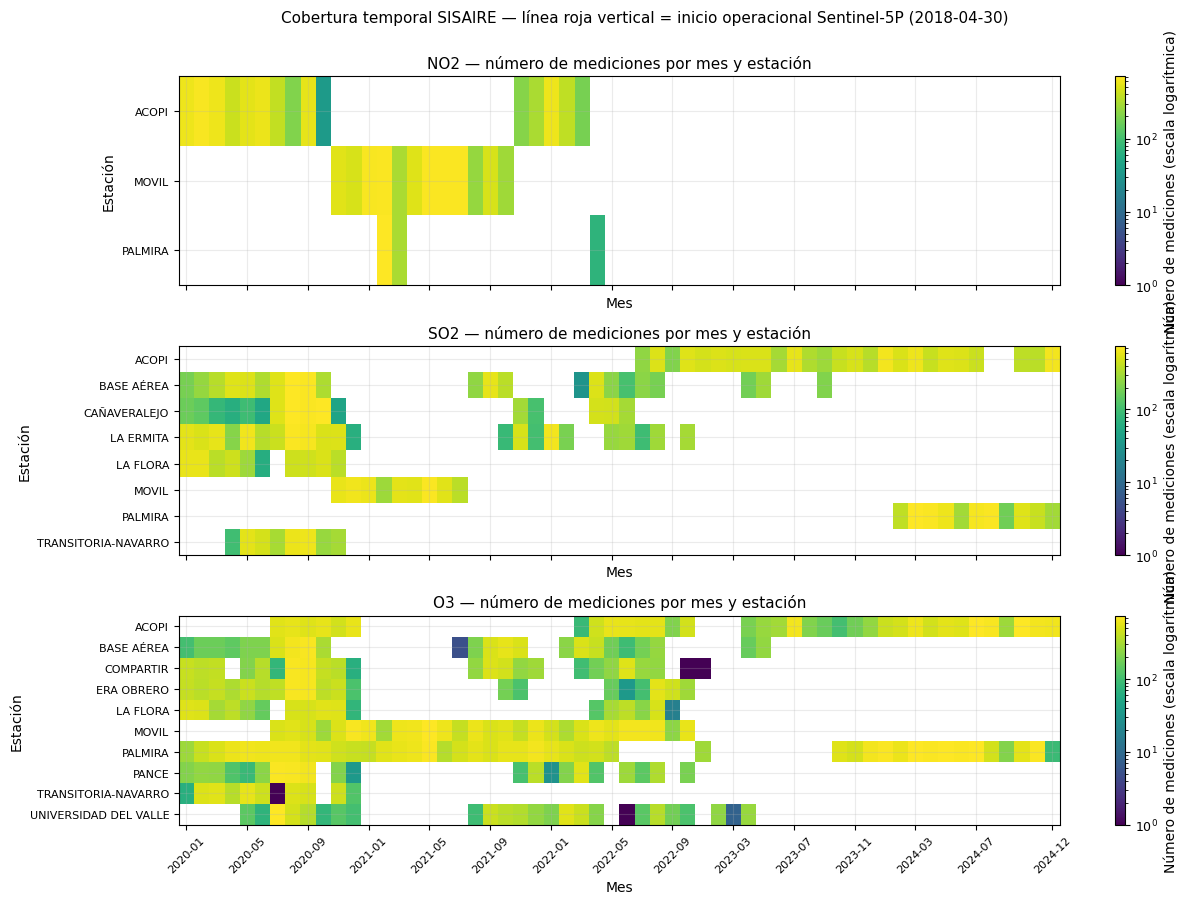

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, poll in zip(axes, ["NO2", "SO2", "O3"]):
    sub = df[df["contaminante"] == poll].copy()
    if sub.empty:
        ax.text(0.5, 0.5, f"Sin datos {poll}", ha="center", transform=ax.transAxes)
        continue
    sub["mes"] = sub["fecha"].dt.to_period("M").dt.to_timestamp()
    piv = sub.pivot_table(index="estacion", columns="mes",
                          values="valor", aggfunc="count").fillna(0)
    if piv.empty:
        continue
    im = ax.imshow(piv.values, aspect="auto", cmap="viridis",
                   norm=LogNorm(vmin=1, vmax=max(piv.values.max(), 2)))
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index, fontsize=8)
    cols = piv.columns
    n_ticks = min(15, len(cols))
    idx = np.linspace(0, len(cols) - 1, n_ticks).astype(int)
    ax.set_xticks(idx)
    ax.set_xticklabels([cols[i].strftime("%Y-%m") for i in idx], rotation=45, fontsize=8)
    ax.set_title(f"{poll} — número de mediciones por mes y estación")
    ax.set_xlabel("Mes")
    ax.set_ylabel("Estación")
    s5p_pos = (pd.Index(cols) < S5P_INICIO).sum()
    if 0 < s5p_pos < len(cols):
        ax.axvline(x=s5p_pos - 0.5, color="red", linestyle="--", alpha=0.7, linewidth=1.5)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Número de mediciones (escala logarítmica)")

fig.suptitle("Cobertura temporal SISAIRE — línea roja vertical = inicio operacional Sentinel-5P (2018-04-30)",
             fontsize=11, y=1.00)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/01_cobertura_temporal.png")
plt.show()

## 7. Mapa de estaciones

Distribución geográfica con los dos BBox del proyecto superpuestos. Estaciones DAGMA en azul
(todas dentro del BBox actual), CVC en rojo (Yumbo cae fuera del BBox actual pero dentro del
propuesto, Palmira queda externa).

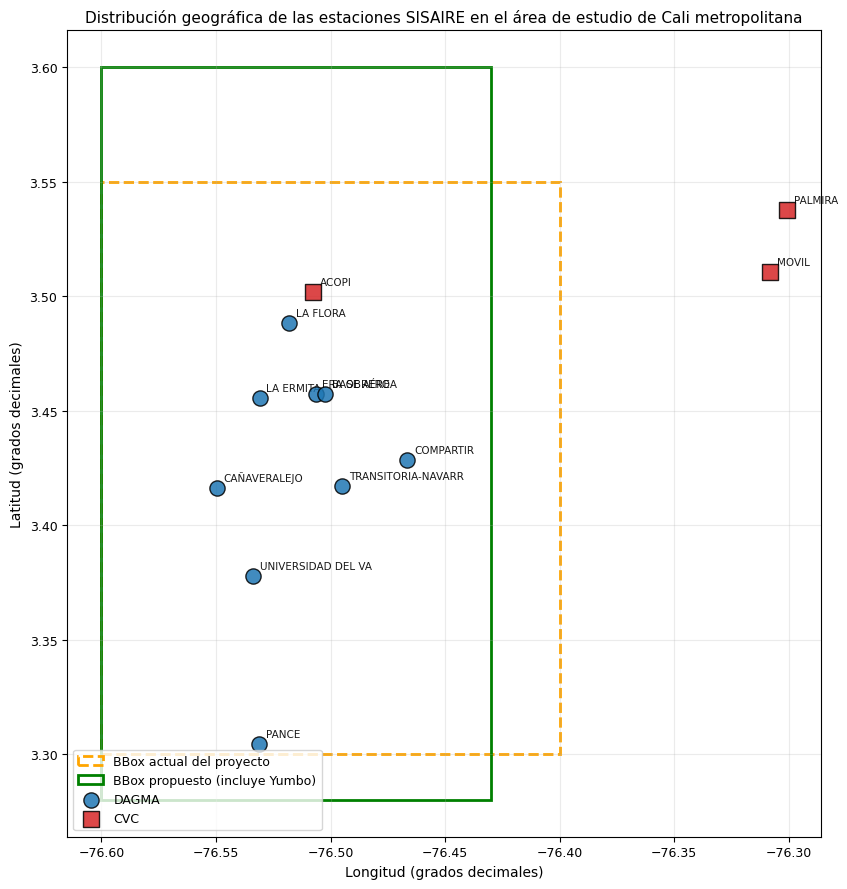

In [10]:
coords = df[["estacion", "autoridad", "latitud", "longitud", "contaminante"]].drop_duplicates()
coords = coords.dropna(subset=["latitud", "longitud"])

fig, ax = plt.subplots(figsize=(11, 9))
bx_a = Rectangle((BBOX_ACTUAL[0], BBOX_ACTUAL[1]),
                 BBOX_ACTUAL[2] - BBOX_ACTUAL[0],
                 BBOX_ACTUAL[3] - BBOX_ACTUAL[1],
                 fill=False, edgecolor="orange", linewidth=2, linestyle="--",
                 label="BBox actual del proyecto")
bx_p = Rectangle((BBOX_PROPUESTO[0], BBOX_PROPUESTO[1]),
                 BBOX_PROPUESTO[2] - BBOX_PROPUESTO[0],
                 BBOX_PROPUESTO[3] - BBOX_PROPUESTO[1],
                 fill=False, edgecolor="green", linewidth=2,
                 label="BBox propuesto (incluye Yumbo)")
ax.add_patch(bx_a)
ax.add_patch(bx_p)

for autoridad, color, marker in [("DAGMA", "tab:blue", "o"),
                                  ("CVC",   "tab:red",  "s")]:
    sub = coords[coords["autoridad"] == autoridad].drop_duplicates(["estacion"])
    ax.scatter(sub["longitud"], sub["latitud"], s=120,
               c=color, marker=marker, edgecolors="black", linewidths=1,
               label=autoridad, zorder=5, alpha=0.85)
    for _, r in sub.iterrows():
        ax.annotate(r["estacion"][:18], (r["longitud"], r["latitud"]),
                    xytext=(5, 5), textcoords="offset points",
                    fontsize=7.5, alpha=0.9)

ax.set_xlabel("Longitud (grados decimales)")
ax.set_ylabel("Latitud (grados decimales)")
ax.set_title("Distribución geográfica de las estaciones SISAIRE en el área de estudio de Cali metropolitana")
ax.legend(loc="lower left", fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/02_mapa_estaciones.png")
plt.show()

## 8. Distribuciones y percentiles para pseudo-labels (Situación 2)

Histogramas post-Sentinel-5P con percentiles marcados (p25, p50, p75, p90, p99). Estos valores
se usan en **Situación 2** para etiquetar tiles Sentinel-2 según concentración del centroide y
construir las clases del entrenamiento contrastivo de GeoVision-CLIP. La línea negra marca el
umbral de la **Resolución 2254/2017**.

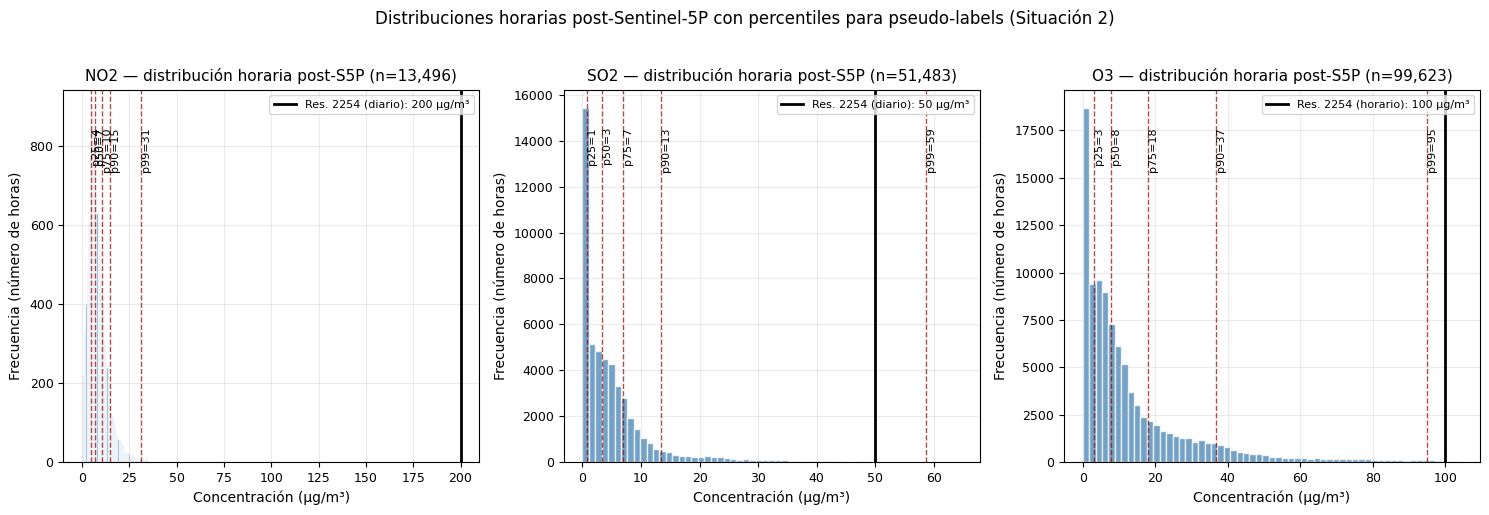


Percentiles para pseudo-labels:


percentil,25,50,75,90,99
contaminante,,,,,
NO2,4.44,6.77,10.27,14.54,31.20
O3,3.00,7.80,17.95,36.83,94.90
SO2,0.70,3.35,6.94,13.35,58.72


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pseudo_table = []
for ax, poll in zip(axes, ["NO2", "SO2", "O3"]):
    sub = df.query("contaminante == @poll and post_s5p")["valor"].dropna()
    if sub.empty:
        ax.text(0.5, 0.5, "sin datos", ha="center", transform=ax.transAxes)
        continue
    bins = np.linspace(0, sub.quantile(0.99) * 1.1, 60)
    ax.hist(sub, bins=bins, color="steelblue", alpha=0.75, edgecolor="white")
    for p in PSEUDO_PERCENTILES:
        v = sub.quantile(p / 100)
        ax.axvline(v, color="darkred", linestyle="--", alpha=0.7, linewidth=1)
        ax.text(v, ax.get_ylim()[1] * 0.9, f"p{p}={v:.0f}",
                rotation=90, fontsize=8, va="top")
        pseudo_table.append({"contaminante": poll, "percentil": p, "valor": round(v, 2)})
    if poll in RES2254 and "diario" in RES2254[poll]:
        umbral = RES2254[poll]["diario"]
        ax.axvline(umbral, color="black", linewidth=2,
                   label=f"Res. 2254 (diario): {umbral} µg/m³")
        ax.legend(fontsize=8, loc="upper right")
    elif poll == "O3":
        ax.axvline(RES2254["O3"]["horario"], color="black", linewidth=2,
                   label=f"Res. 2254 (horario): {RES2254['O3']['horario']} µg/m³")
        ax.legend(fontsize=8, loc="upper right")
    ax.set_title(f"{poll} — distribución horaria post-S5P (n={len(sub):,d})")
    ax.set_xlabel("Concentración (µg/m³)")
    ax.set_ylabel("Frecuencia (número de horas)")
fig.suptitle("Distribuciones horarias post-Sentinel-5P con percentiles para pseudo-labels (Situación 2)",
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/03_distribuciones.png")
plt.show()

pseudo_df = pd.DataFrame(pseudo_table)
pseudo_df.to_csv(f"{OUT_DIR}/tabla_percentiles_pseudolabels.csv", index=False)
print("\nPercentiles para pseudo-labels:")
pseudo_df.pivot(index="contaminante", columns="percentil", values="valor")

## 9. Ciclo diurno

Promedio horario por estación. Patrones físicos esperados:

- **NO₂**: pico AM/PM por tráfico vehicular
- **O₃**: pico mediodía-tarde por fotólisis (radiación UV intensa convierte NOₓ en O₃)
- **SO₂**: variabilidad menor, asociada a fuentes industriales puntuales

Esos patrones son **señal valiosa** que el ConvLSTM debe aprender.

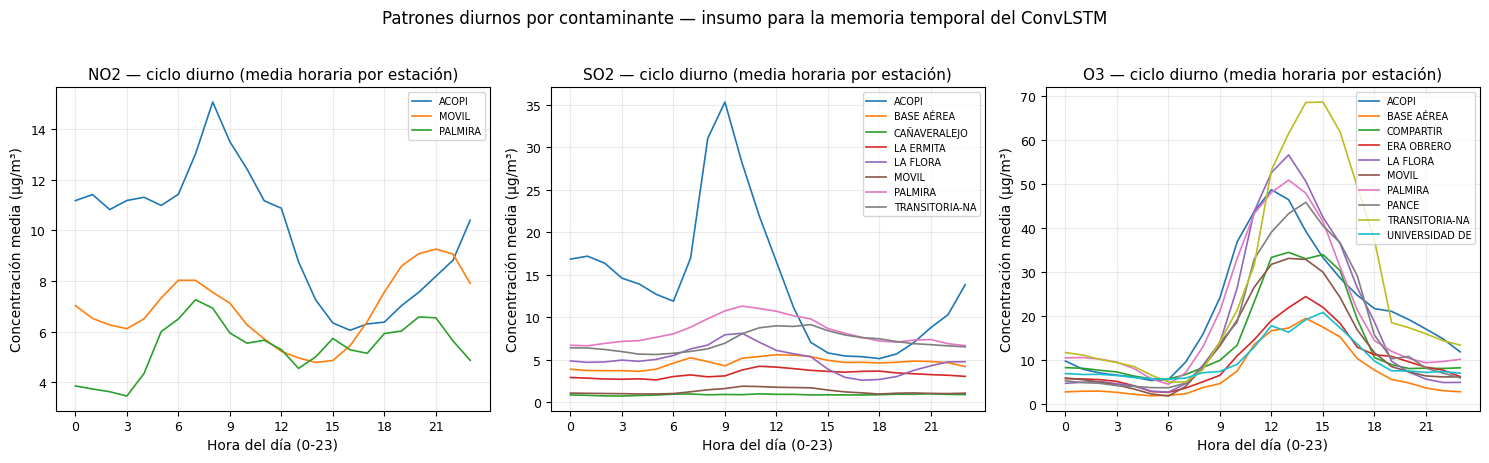

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
for ax, poll in zip(axes, ["NO2", "SO2", "O3"]):
    sub = df.query("contaminante == @poll and post_s5p").dropna(subset=["valor"]).copy()
    if sub.empty:
        ax.text(0.5, 0.5, "sin datos", ha="center", transform=ax.transAxes)
        continue
    sub["hora"] = sub["fecha"].dt.hour
    for est, grp in sub.groupby("estacion"):
        if len(grp) < 100:
            continue
        ciclo = grp.groupby("hora")["valor"].agg(["mean", "std"])
        ax.plot(ciclo.index, ciclo["mean"], label=est[:14], linewidth=1.2)
    ax.set_title(f"{poll} — ciclo diurno (media horaria por estación)")
    ax.set_xlabel("Hora del día (0-23)")
    ax.set_ylabel("Concentración media (µg/m³)")
    ax.set_xticks(range(0, 24, 3))
    ax.legend(fontsize=7, ncol=1, loc="upper right")
fig.suptitle("Patrones diurnos por contaminante — insumo para la memoria temporal del ConvLSTM",
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/04_ciclo_diurno.png")
plt.show()

## 10. Estacionalidad mensual

Promedio por mes calendario. El sombreado naranja marca la **temporada típica de quemas de caña
de azúcar en el Valle del Cauca** (jun-ago, dic-feb). Si el pipeline de zafra está activo, esperarías
ver mayor SO₂ y partículas en esos meses — es una de las **fuentes regionales** que la
fundamentación del proyecto menciona explícitamente.

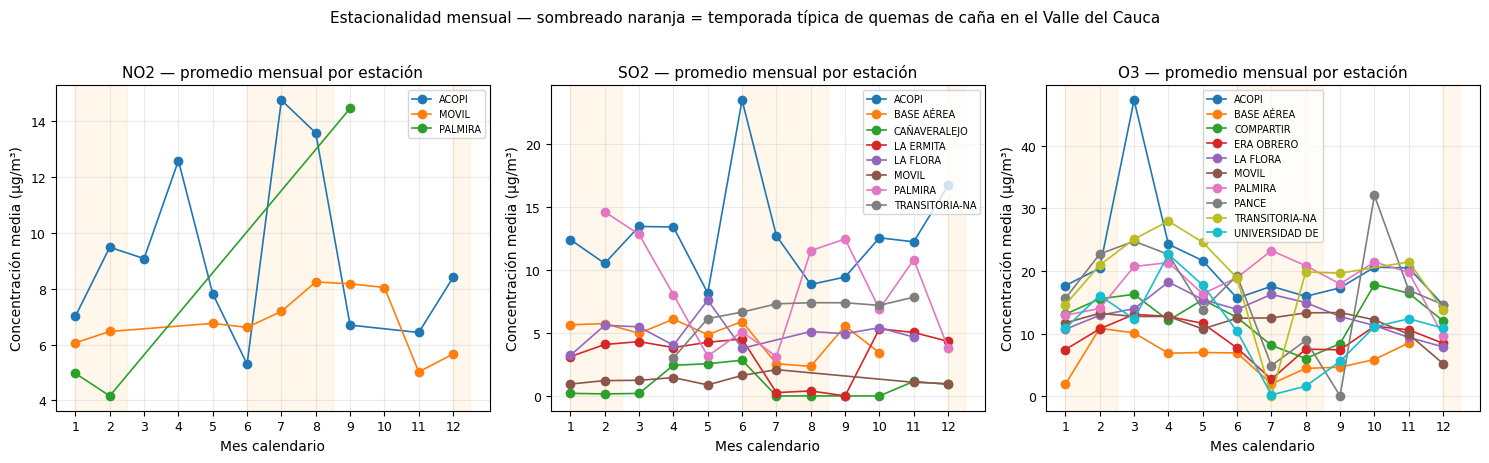

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, poll in zip(axes, ["NO2", "SO2", "O3"]):
    sub = df.query("contaminante == @poll and post_s5p").dropna(subset=["valor"]).copy()
    if sub.empty:
        ax.text(0.5, 0.5, "sin datos", ha="center", transform=ax.transAxes)
        continue
    sub["mes"] = sub["fecha"].dt.month
    for est, grp in sub.groupby("estacion"):
        if len(grp) < 200:
            continue
        mensual = grp.groupby("mes")["valor"].mean()
        ax.plot(mensual.index, mensual.values, marker="o", label=est[:14], linewidth=1.2)
    ax.set_title(f"{poll} — promedio mensual por estación")
    ax.set_xlabel("Mes calendario")
    ax.set_ylabel("Concentración media (µg/m³)")
    ax.set_xticks(range(1, 13))
    ax.legend(fontsize=7, loc="best")
    for ini, fin in [(1, 2.5), (6, 8.5), (12, 12.5)]:
        ax.axvspan(ini, fin, alpha=0.08, color="orange")
fig.suptitle("Estacionalidad mensual — sombreado naranja = temporada típica de quemas de caña en el Valle del Cauca",
             fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/05_estacionalidad.png")
plt.show()

## 11. Correlaciones entre estaciones (Situación 3 · Kriging)

Matriz de Pearson sobre series alineadas a frecuencia horaria. Las correlaciones altas entre
estaciones cercanas justifican el supuesto de **autocorrelación espacial** del Kriging.
Si dos estaciones cercanas no correlacionan, es señal de fuentes locales fuertes que el modelo
profundo deberá capturar.

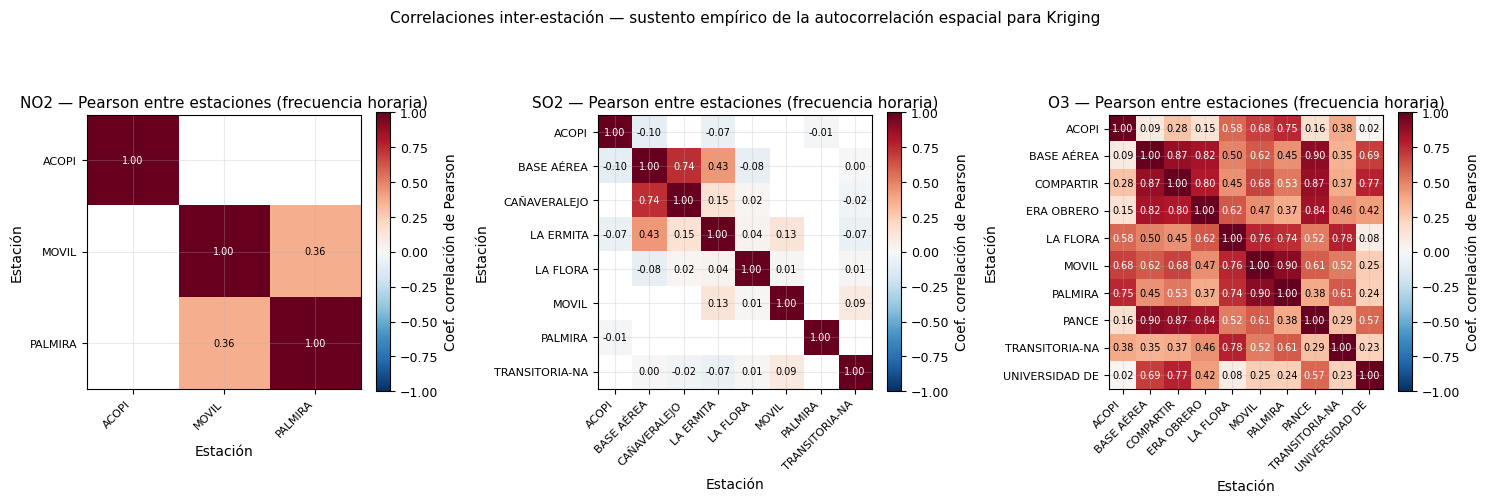

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
correlaciones_data = []
for ax, poll in zip(axes, ["NO2", "SO2", "O3"]):
    sub = df.query("contaminante == @poll and post_s5p").dropna(subset=["valor"]).copy()
    if sub.empty or sub["estacion"].nunique() < 2:
        ax.text(0.5, 0.5, "N estaciones < 2", ha="center", transform=ax.transAxes)
        ax.set_title(f"{poll} — correlaciones no estimables")
        continue
    sub["fecha_h"] = sub["fecha"].dt.floor("h")
    wide = sub.pivot_table(index="fecha_h", columns="estacion",
                           values="valor", aggfunc="mean")
    wide = wide.loc[:, wide.count() >= 1000]
    if wide.shape[1] < 2:
        ax.text(0.5, 0.5, "estaciones con <1000 obs", ha="center", transform=ax.transAxes)
        continue
    corr = wide.corr(min_periods=200)
    im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_xticks(range(len(corr.columns)))
    ax.set_xticklabels([c[:14] for c in corr.columns], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(corr.columns)))
    ax.set_yticklabels([c[:14] for c in corr.columns], fontsize=8)
    ax.set_title(f"{poll} — Pearson entre estaciones (frecuencia horaria)")
    ax.set_xlabel("Estación")
    ax.set_ylabel("Estación")
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            v = corr.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if abs(v) > 0.5 else "black")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046)
    cbar.set_label("Coef. correlación de Pearson")
    for c1 in corr.columns:
        for c2 in corr.columns:
            if c1 < c2:
                correlaciones_data.append({
                    "contaminante": poll, "estacion_a": c1, "estacion_b": c2,
                    "corr_pearson": round(corr.loc[c1, c2], 3),
                })
fig.suptitle("Correlaciones inter-estación — sustento empírico de la autocorrelación espacial para Kriging",
             fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/06_correlaciones.png")
plt.show()
pd.DataFrame(correlaciones_data).to_csv(f"{OUT_DIR}/tabla_correlaciones.csv", index=False)

## 12. Solapamiento temporal entre estaciones (Situación 3 · LOO-CV)

Matriz N×N con el número de **días en común** entre cada par de estaciones post-Sentinel-5P.
Si la celda (Yumbo, Univalle) es 0, eso confirma que las dos estaciones de NO₂ no se solapan
temporalmente — y esa es la justificación técnica para usar **TSCV en lugar de LOO-CV puro
para NO₂**.

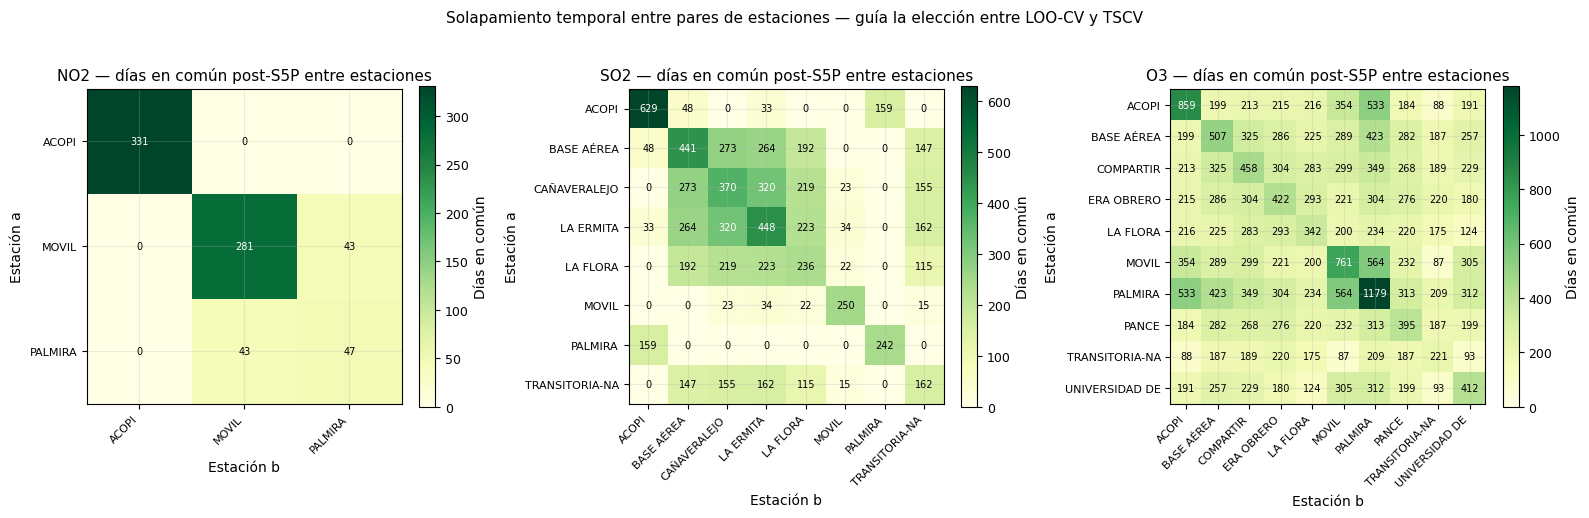

In [15]:
rows = []
for poll in ["NO2", "SO2", "O3"]:
    sub = df.query("contaminante == @poll and post_s5p").dropna(subset=["valor"]).copy()
    ests = sorted(sub["estacion"].dropna().unique())
    sub["dia"] = sub["fecha"].dt.floor("D")
    dias_por_est = {e: set(sub.loc[sub["estacion"] == e, "dia"].unique()) for e in ests}
    for e1 in ests:
        for e2 in ests:
            rows.append({
                "contaminante": poll, "estacion_a": e1, "estacion_b": e2,
                "dias_comunes": len(dias_por_est[e1] & dias_por_est[e2]),
                "dias_a": len(dias_por_est[e1]),
                "dias_b": len(dias_por_est[e2]),
            })
sol = pd.DataFrame(rows)
sol.to_csv(f"{OUT_DIR}/tabla_solapamiento.csv", index=False)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, poll in zip(axes, ["NO2", "SO2", "O3"]):
    s = sol[sol["contaminante"] == poll]
    if s.empty:
        ax.text(0.5, 0.5, "sin datos", ha="center", transform=ax.transAxes)
        continue
    piv = s.pivot(index="estacion_a", columns="estacion_b", values="dias_comunes")
    if piv.empty:
        continue
    im = ax.imshow(piv.values, cmap="YlGn", vmin=0)
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([c[:14] for c in piv.columns], rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels([c[:14] for c in piv.index], fontsize=8)
    ax.set_title(f"{poll} — días en común post-S5P entre estaciones")
    ax.set_xlabel("Estación b")
    ax.set_ylabel("Estación a")
    for i in range(len(piv.index)):
        for j in range(len(piv.columns)):
            v = piv.values[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{int(v)}", ha="center", va="center",
                        fontsize=7,
                        color="white" if v > piv.values.max() * 0.5 else "black")
    cbar = plt.colorbar(im, ax=ax, fraction=0.046)
    cbar.set_label("Días en común")
fig.suptitle("Solapamiento temporal entre pares de estaciones — guía la elección entre LOO-CV y TSCV",
             fontsize=11, y=1.02)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/07_solapamiento_temporal.png")
plt.show()

## 13. Outliers físicos y excedencias normativas

Boxplot por estación con dos líneas de referencia:

- **Roja** (límite físico): valores > este umbral son sospechosos de error de instrumento
- **Naranja** (Resolución 2254): excedencias del límite legal — útil para el discurso de salud pública del informe

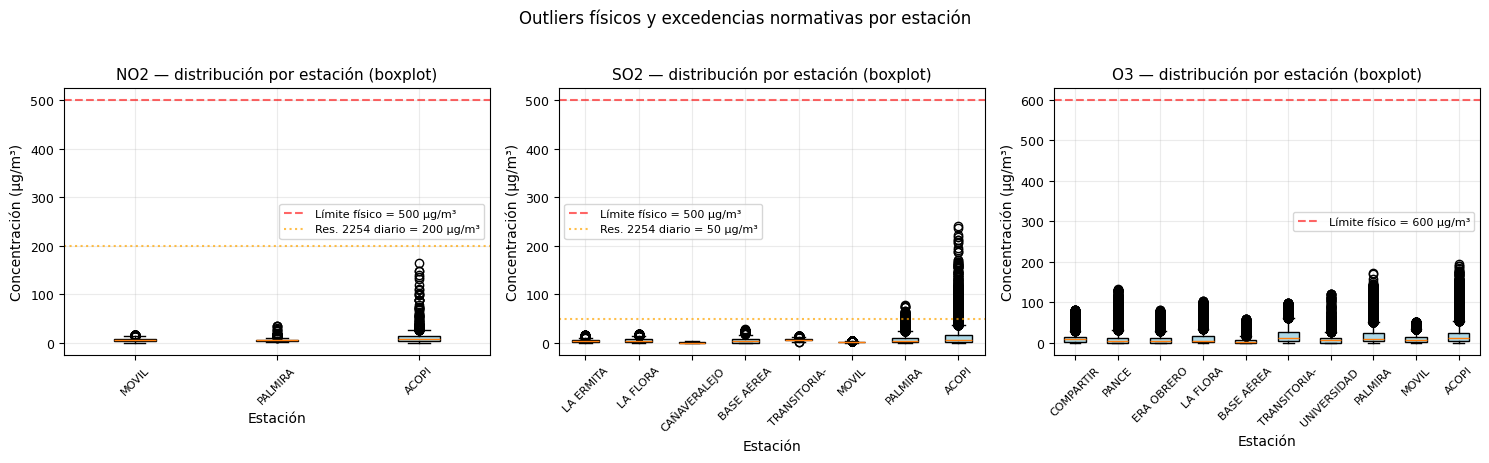

In [16]:
rows_out = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, poll in zip(axes, ["NO2", "SO2", "O3"]):
    sub = df.query("contaminante == @poll").dropna(subset=["valor"]).copy()
    if sub.empty:
        continue
    lo, hi = RANGO_FISICO[poll]
    sub["outlier"] = ~sub["valor"].between(lo, hi)
    ests = sub["estacion"].unique()
    data = [sub.loc[sub["estacion"] == e, "valor"].values for e in ests]
    bp = ax.boxplot(data, labels=[e[:12] for e in ests],
                     showfliers=True, patch_artist=True)
    for patch in bp["boxes"]:
        patch.set_facecolor("lightblue")
    ax.axhline(hi, color="red", linestyle="--", alpha=0.6,
               label=f"Límite físico = {hi} µg/m³")
    if poll in RES2254 and "diario" in RES2254[poll]:
        ax.axhline(RES2254[poll]["diario"], color="orange", linestyle=":",
                   alpha=0.7, label=f"Res. 2254 diario = {RES2254[poll]['diario']} µg/m³")
    ax.set_title(f"{poll} — distribución por estación (boxplot)")
    ax.set_xlabel("Estación")
    ax.set_ylabel("Concentración (µg/m³)")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    ax.legend(fontsize=8)
    for e in ests:
        ssub = sub[sub["estacion"] == e]
        rows_out.append({
            "contaminante": poll, "estacion": e,
            "n_total": len(ssub),
            "n_outliers_fisicos": int(ssub["outlier"].sum()),
            "pct_outliers": round(ssub["outlier"].mean() * 100, 2),
            "n_excede_2254": int((ssub["valor"] > RES2254.get(poll, {}).get("diario", 1e9)).sum()),
        })
fig.suptitle("Outliers físicos y excedencias normativas por estación",
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/08_outliers.png")
plt.show()
pd.DataFrame(rows_out).to_csv(f"{OUT_DIR}/tabla_outliers.csv", index=False)

## 14. Autocorrelación temporal y estacionariedad (Situación 3 · ConvLSTM)

Insumo directo para defender la arquitectura ConvLSTM con memoria de **8 fechas** que pide el PDF:

- **ACF/PACF**: identifica el orden temporal con dependencia significativa.
- **ADF (Dickey-Fuller aumentado)**: H₀ = la serie tiene raíz unitaria (no estacionaria).
- **KPSS**: H₀ = la serie es estacionaria. Diagnóstico complementario al ADF.

Una serie horaria de contaminante típica es no estacionaria por ciclo diurno fuerte; el contraste
entre la serie original y su primera diferencia (`diff(1)`) muestra si la diferenciación elimina
la tendencia. Estos resultados orientan si el ConvLSTM debe trabajar sobre la serie cruda o
sobre anomalías respecto a la media diurna.

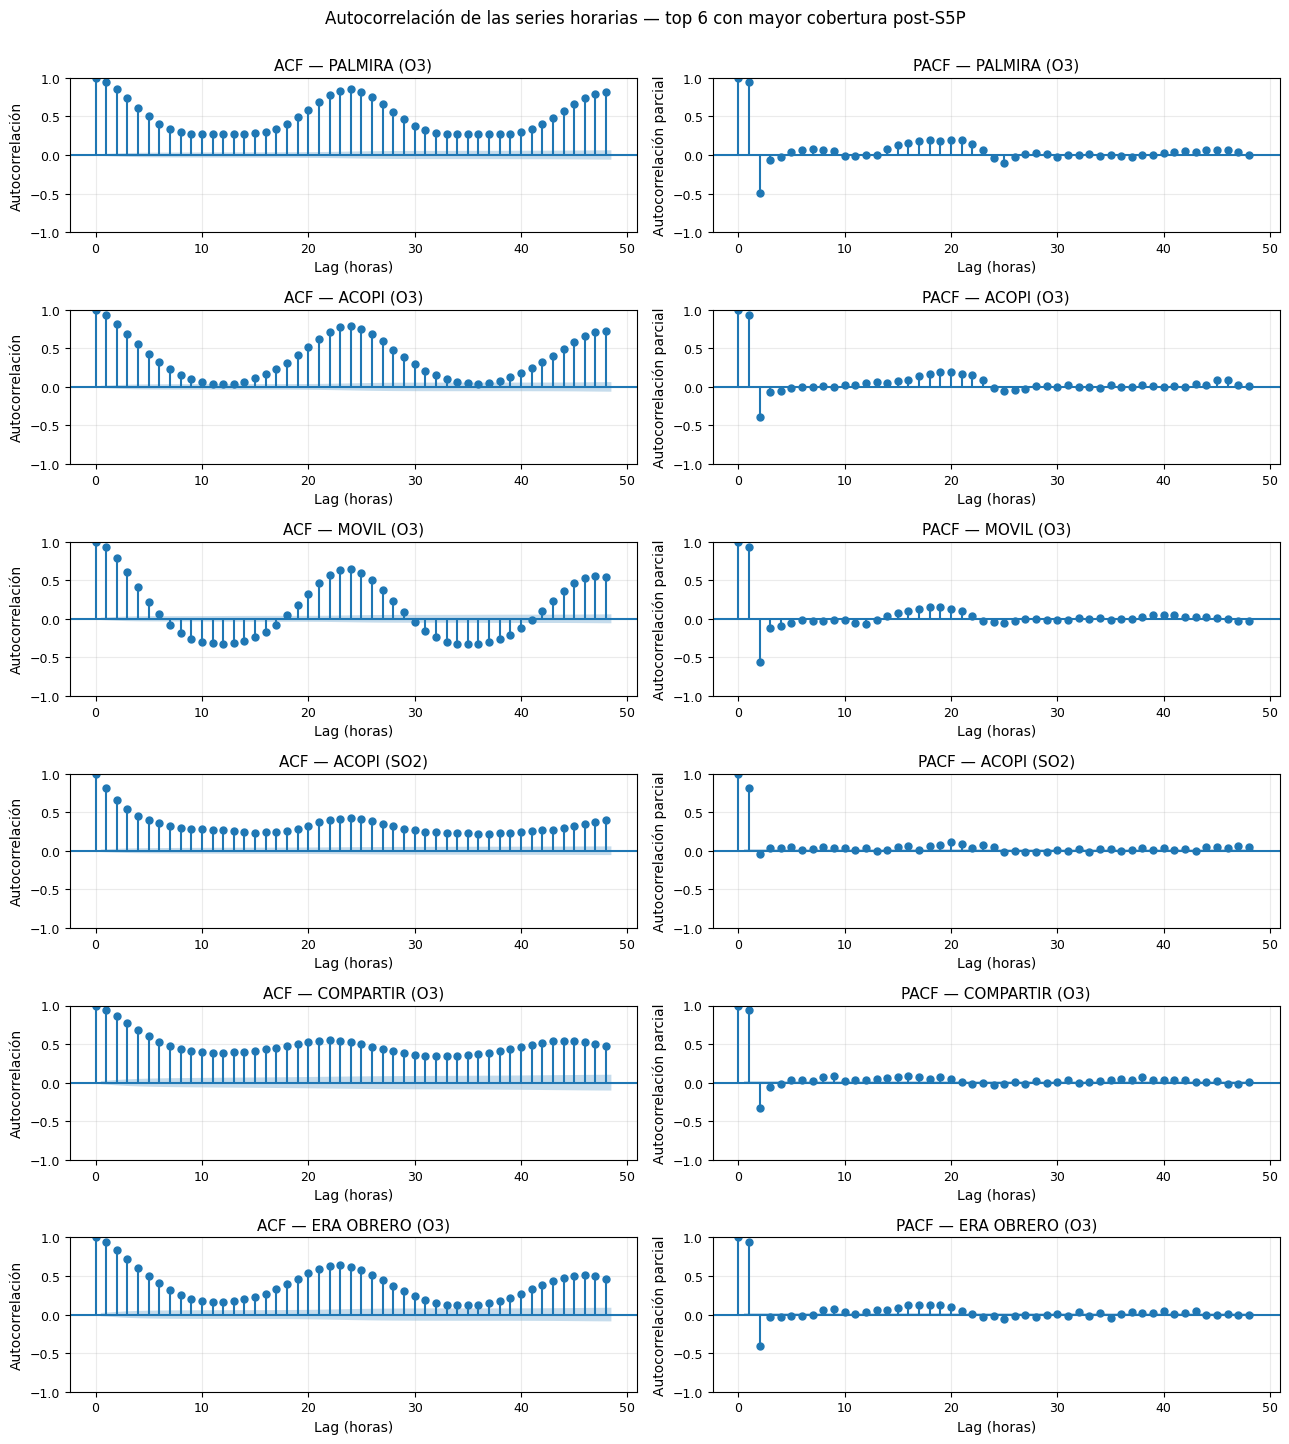


ADF (H0: raíz unitaria, p<0.05 -> estacionaria) y KPSS (H0: estacionaria, p<0.05 -> NO estacionaria):
  estacion contaminante transformacion     n  adf_p  kpss_p
   PALMIRA           O3       original 26942    0.0    0.01
   PALMIRA           O3         diff_1 26941    0.0    0.10
     ACOPI           O3       original 19283    0.0    0.01
     ACOPI           O3         diff_1 19282    0.0    0.10
     MOVIL           O3       original 16555    0.0    0.01
     MOVIL           O3         diff_1 16554    0.0    0.10
     ACOPI          SO2       original 14350    0.0    0.01
     ACOPI          SO2         diff_1 14349    0.0    0.10
 COMPARTIR           O3       original  8872    0.0    0.01
 COMPARTIR           O3         diff_1  8871    0.0    0.10
ERA OBRERO           O3       original  8808    0.0    0.01
ERA OBRERO           O3         diff_1  8807    0.0    0.10


In [17]:
def test_estacionariedad(serie, n_lags=24):
    """Devuelve p-valores de ADF y KPSS para una serie."""
    serie = pd.Series(serie).dropna()
    if len(serie) < 100:
        return None
    try:
        adf_p = adfuller(serie, autolag="AIC", maxlag=n_lags)[1]
    except Exception:
        adf_p = np.nan
    try:
        kpss_p = kpss(serie, regression="c", nlags="auto")[1]
    except Exception:
        kpss_p = np.nan
    return {"n": len(serie),
            "adf_p":  round(float(adf_p),  4),
            "kpss_p": round(float(kpss_p), 4)}


# Top 6 series por cobertura limpia
top_series = (silver_log.query("serie_aceptada")
                       .sort_values("n_validos_finales", ascending=False)
                       .head(6))

estacionariedad_rows = []
n_top = len(top_series)
fig, axes = plt.subplots(n_top, 2, figsize=(13, 2.4 * max(n_top, 1)))
if n_top == 1:
    axes = axes.reshape(1, -1)

for i, (_, row) in enumerate(top_series.iterrows()):
    serie = (df_silver.query("estacion == @row.estacion and contaminante == @row.contaminante")
                     .set_index("fecha")["valor_imputado"].dropna())
    if len(serie) < 100:
        continue
    plot_acf(serie, lags=48, ax=axes[i, 0],
             title=f"ACF — {row.estacion} ({row.contaminante})")
    axes[i, 0].set_xlabel("Lag (horas)")
    axes[i, 0].set_ylabel("Autocorrelación")

    plot_pacf(serie, lags=48, ax=axes[i, 1], method="ywm",
              title=f"PACF — {row.estacion} ({row.contaminante})")
    axes[i, 1].set_xlabel("Lag (horas)")
    axes[i, 1].set_ylabel("Autocorrelación parcial")

    s_orig = test_estacionariedad(serie)
    s_diff = test_estacionariedad(serie.diff().dropna())
    if s_orig:
        estacionariedad_rows.append({
            "estacion": row.estacion, "contaminante": row.contaminante,
            "transformacion": "original", **s_orig,
        })
    if s_diff:
        estacionariedad_rows.append({
            "estacion": row.estacion, "contaminante": row.contaminante,
            "transformacion": "diff_1", **s_diff,
        })

fig.suptitle("Autocorrelación de las series horarias — top 6 con mayor cobertura post-S5P",
             fontsize=12, y=1.00)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/09_acf_pacf.png")
plt.show()

estacionariedad = pd.DataFrame(estacionariedad_rows)
estacionariedad.to_csv(f"{OUT_DIR}/tabla_estacionariedad.csv", index=False)
print("\nADF (H0: raíz unitaria, p<0.05 -> estacionaria) y "
      "KPSS (H0: estacionaria, p<0.05 -> NO estacionaria):")
print(estacionariedad.to_string(index=False))

## 15. Variograma experimental exploratorio (Situación 3 · Kriging)

Cuantifica la **autocorrelación espacial** de las concentraciones medias por estación. El
variograma experimental se ajusta con tres modelos teóricos (esférico, exponencial,
gaussiano); el de menor RMSE en el ajuste se reporta como referencia inicial. El modelo
final se reajustará en Situación 3 sobre los residuos del ConvLSTM, no sobre la concentración
cruda — esta corrida solo verifica que existe estructura espacial estimable.

Parámetros del variograma:
- **Nugget**: discontinuidad en `h=0` (ruido de medición + variabilidad sub-escala).
- **Sill**: meseta a la que tiende `γ(h)` cuando las observaciones se vuelven independientes.
- **Rango**: distancia a partir de la cual `γ(h) ≈ sill` (alcance de la dependencia espacial).

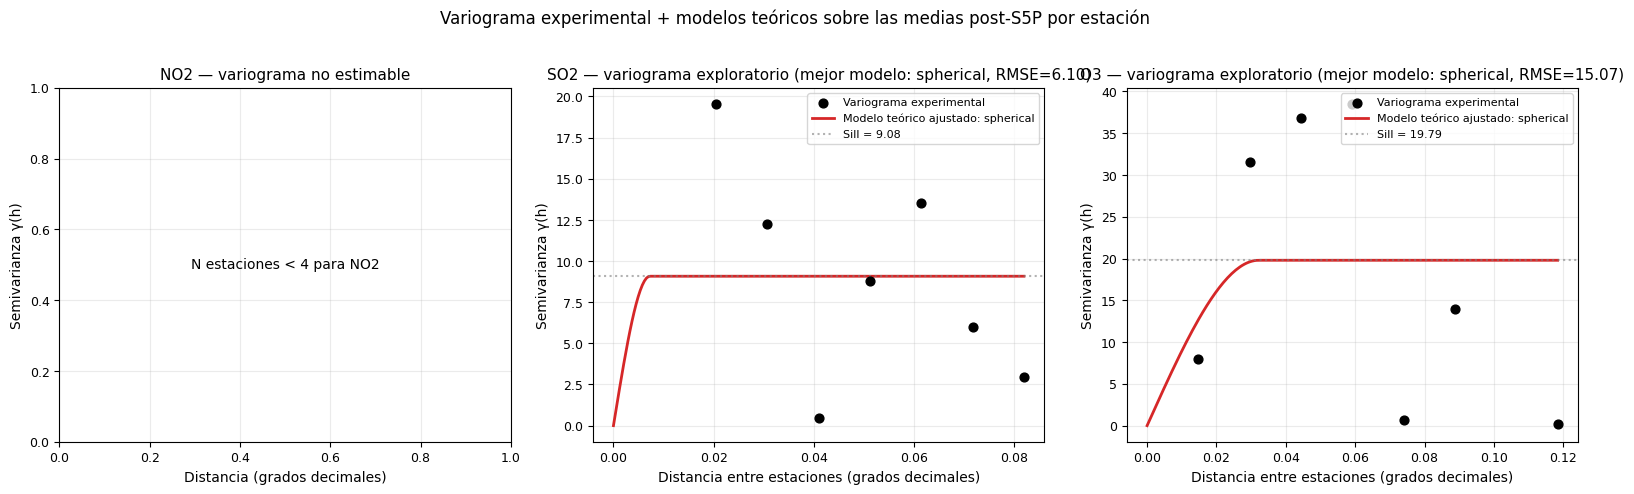


Parámetros del variograma por contaminante y modelo:
contaminante      modelo    rmse  rango    sill  nugget
         SO2   spherical  6.1002 0.0073  9.0778     0.0
         SO2 exponential  6.1002 0.0014  9.0778     0.0
         SO2    gaussian  6.1002 0.0008  9.0778     0.0
          O3   spherical 15.0682 0.0322 19.7924     0.0
          O3 exponential 15.5426 0.0006 18.5167     0.0
          O3    gaussian 15.0710 0.0316 19.9539     0.0


In [18]:
def variograma_estacion(df_silver, contaminante,
                         modelos=("spherical", "exponential", "gaussian")):
    """Ajusta variograma sobre las medias post-S5P por estación.
    Devuelve dict {modelo: {parametros}} y la tabla de medias."""
    sub = df_silver.query("contaminante == @contaminante and valor_imputado.notna()",
                           engine="python")
    medias = (sub.groupby("estacion")[["latitud", "longitud", "valor_imputado"]]
                 .mean().dropna())
    if len(medias) < 4:
        return None, medias
    coords = medias[["longitud", "latitud"]].values
    valores = medias["valor_imputado"].values
    resultados = {}
    for modelo in modelos:
        try:
            V = skg.Variogram(coords, valores, model=modelo, n_lags=8,
                              normalize=False, maxlag="median")
            resultados[modelo] = {
                "rmse":   float(V.rmse),
                "rango":  float(V.parameters[0]),
                "sill":   float(V.parameters[1]),
                "nugget": float(V.parameters[2]),
                "objeto": V,
            }
        except Exception as e:
            resultados[modelo] = {"error": str(e)}
    return resultados, medias


fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
variog_rows = []
for ax, poll in zip(axes, ["NO2", "SO2", "O3"]):
    res, medias = variograma_estacion(df_silver, poll)
    if not res or all("error" in r for r in res.values()):
        ax.text(0.5, 0.5, f"N estaciones < 4 para {poll}",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"{poll} — variograma no estimable")
        ax.set_xlabel("Distancia (grados decimales)")
        ax.set_ylabel("Semivarianza γ(h)")
        continue

    candidatos = {m: r for m, r in res.items() if "error" not in r}
    mejor = min(candidatos, key=lambda m: candidatos[m]["rmse"])
    V = candidatos[mejor]["objeto"]
    bins = V.bins
    exp  = V.experimental
    ax.scatter(bins, exp, c="black", s=40, label="Variograma experimental", zorder=5)
    x_fino = np.linspace(0, max(bins), 200)
    ax.plot(x_fino, V.transform(x_fino), color="tab:red", linewidth=2,
            label=f"Modelo teórico ajustado: {mejor}")
    ax.axhline(candidatos[mejor]["sill"], color="grey", linestyle=":",
               alpha=0.6, label=f"Sill = {candidatos[mejor]['sill']:.2f}")
    ax.set_xlabel("Distancia entre estaciones (grados decimales)")
    ax.set_ylabel("Semivarianza γ(h)")
    ax.set_title(f"{poll} — variograma exploratorio (mejor modelo: {mejor}, "
                 f"RMSE={candidatos[mejor]['rmse']:.2f})")
    ax.legend(fontsize=8)

    for m, r in candidatos.items():
        variog_rows.append({"contaminante": poll, "modelo": m,
                            **{k: round(v, 4) for k, v in r.items() if k != "objeto"}})

fig.suptitle("Variograma experimental + modelos teóricos sobre las medias post-S5P por estación",
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/10_variograma_exploratorio.png")
plt.show()

variog_df = pd.DataFrame(variog_rows)
variog_df.to_csv(f"{OUT_DIR}/tabla_variograma.csv", index=False)
print("\nParámetros del variograma por contaminante y modelo:")
print(variog_df.to_string(index=False))

## 16. Autocorrelación espacial: Moran I y LISA (Situación 3 · KPI)

Anticipa el KPI de Situación 3 (Moran I > 0.30 con p < 0.05). Se calcula sobre las medias
post-S5P de cada estación; los pesos espaciales se construyen con **K vecinos más cercanos**
(K = mín(4, n−1)) y se normalizan por filas. La significancia se evalúa con **permutation
test** (n=999) — no asume distribución gaussiana de las concentraciones.

LISA (Local Indicators of Spatial Association) descompone el Moran I global en contribuciones
locales y clasifica cada estación en cuatro cuadrantes:

- **HH (alto-alto)**: estación con concentración alta rodeada de vecinos también altos → cluster crítico.
- **LL (bajo-bajo)**: cluster de baja concentración.
- **HL / LH**: outliers espaciales (zona alta rodeada de vecinos bajos o viceversa).

Solo las clasificaciones con `p_sim < 0.05` se reportan como significativas.

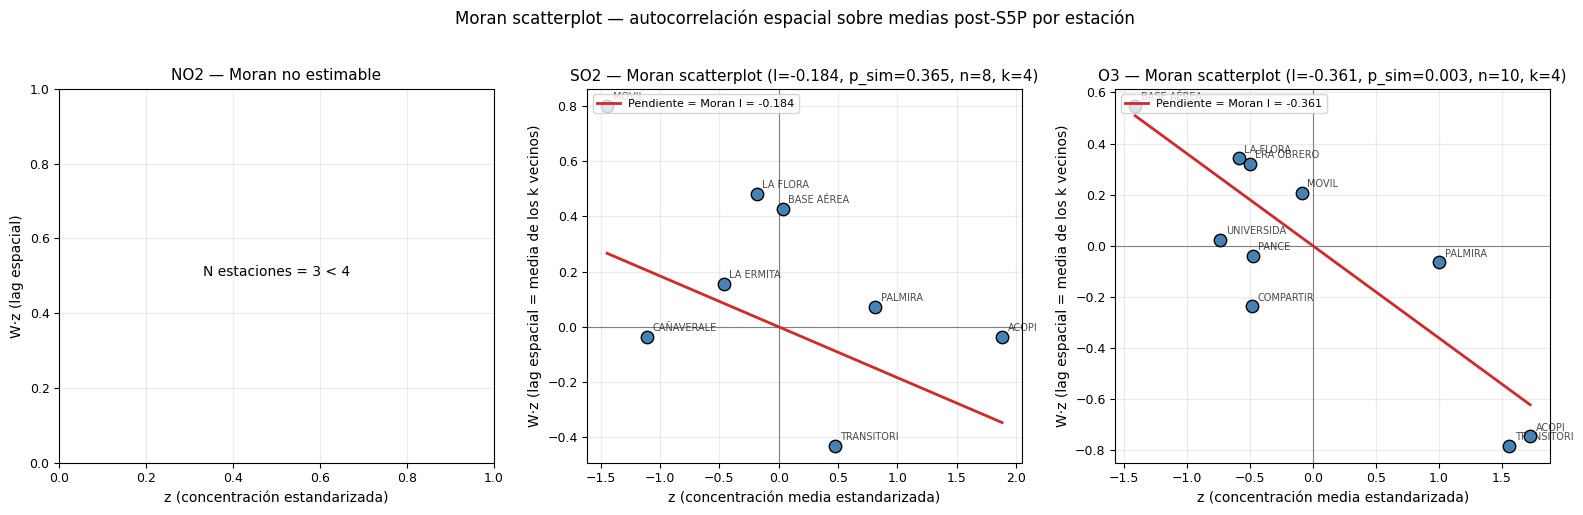


Moran I global por contaminante:
contaminante  n_estaciones  k_vecinos  moran_I  p_sim  z_sim  n_HH_sig  n_LL_sig  n_HL_sig  n_LH_sig
         SO2             8          4  -0.1843  0.365 -0.421         0         0         0         1
          O3            10          4  -0.3608  0.003 -2.064         0         0         1         0

LISA — clasificación por estación (HH=alto-alto, LL=bajo-bajo, HL/LH=outliers):
contaminante              estacion cuadrante  p_sim  significativo
         SO2                 ACOPI        HL  0.238          False
         SO2            BASE AÉREA        HH  0.171          False
         SO2          CAÑAVERALEJO        LL  0.307          False
         SO2             LA ERMITA        LH  0.427          False
         SO2              LA FLORA        LH  0.130          False
         SO2                 MOVIL        LH  0.001           True
         SO2               PALMIRA        HH  0.336          False
         SO2   TRANSITORIA-NAVARRO        HL  

In [19]:
moran_rows = []
lisa_rows = []
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, poll in zip(axes, ["NO2", "SO2", "O3"]):
    sub = df_silver.query("contaminante == @poll and valor_imputado.notna()",
                          engine="python")
    medias = (sub.groupby("estacion")[["latitud", "longitud", "valor_imputado"]]
                 .mean().dropna())
    n = len(medias)
    if n < 4:
        ax.text(0.5, 0.5, f"N estaciones = {n} < 4",
                ha="center", transform=ax.transAxes)
        ax.set_title(f"{poll} — Moran no estimable")
        ax.set_xlabel("z (concentración estandarizada)")
        ax.set_ylabel("W·z (lag espacial)")
        continue

    coords  = medias[["longitud", "latitud"]].values
    valores = medias["valor_imputado"].values

    # KNN weights normalizados por filas
    k = max(2, min(4, n - 1))
    w = libpysal.weights.KNN.from_array(coords, k=k)
    w.transform = "r"

    moran = Moran(valores, w, permutations=999)
    lisa  = Moran_Local(valores, w, permutations=999, seed=SEED)

    z = (valores - valores.mean()) / valores.std()
    wz = libpysal.weights.lag_spatial(w, z)
    ax.scatter(z, wz, s=80, c="steelblue", edgecolor="black", zorder=5)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.axvline(0, color="grey", linewidth=0.8)
    xs = np.linspace(z.min(), z.max(), 50)
    ax.plot(xs, moran.I * xs, color="tab:red", linewidth=2,
            label=f"Pendiente = Moran I = {moran.I:.3f}")
    for (xi, yi, est) in zip(z, wz, medias.index):
        ax.annotate(est[:10], (xi, yi), xytext=(4, 4),
                    textcoords="offset points", fontsize=7, alpha=0.7)
    ax.set_xlabel("z (concentración media estandarizada)")
    ax.set_ylabel("W·z (lag espacial = media de los k vecinos)")
    ax.set_title(f"{poll} — Moran scatterplot "
                 f"(I={moran.I:.3f}, p_sim={moran.p_sim:.3f}, n={n}, k={k})")
    ax.legend(fontsize=8, loc="upper left")

    moran_rows.append({
        "contaminante": poll, "n_estaciones": n, "k_vecinos": k,
        "moran_I":  round(float(moran.I),     4),
        "p_sim":    round(float(moran.p_sim), 4),
        "z_sim":    round(float(moran.z_sim), 3),
        "n_HH_sig": int(((lisa.q == 1) & (lisa.p_sim < 0.05)).sum()),
        "n_LL_sig": int(((lisa.q == 3) & (lisa.p_sim < 0.05)).sum()),
        "n_HL_sig": int(((lisa.q == 4) & (lisa.p_sim < 0.05)).sum()),
        "n_LH_sig": int(((lisa.q == 2) & (lisa.p_sim < 0.05)).sum()),
    })
    cuadrante_map = {1: "HH", 2: "LH", 3: "LL", 4: "HL"}
    for est, q, p in zip(medias.index, lisa.q, lisa.p_sim):
        lisa_rows.append({
            "contaminante": poll, "estacion": est,
            "cuadrante": cuadrante_map[q],
            "p_sim": round(float(p), 4),
            "significativo": bool(p < 0.05),
        })

fig.suptitle("Moran scatterplot — autocorrelación espacial sobre medias post-S5P por estación",
             fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(f"{OUT_DIR}/11_moran_scatterplot.png")
plt.show()

moran_df = pd.DataFrame(moran_rows)
moran_df.to_csv(f"{OUT_DIR}/tabla_moran.csv", index=False)
print("\nMoran I global por contaminante:")
print(moran_df.to_string(index=False))

lisa_df = pd.DataFrame(lisa_rows)
lisa_df.to_csv(f"{OUT_DIR}/tabla_lisa.csv", index=False)
print("\nLISA — clasificación por estación (HH=alto-alto, LL=bajo-bajo, HL/LH=outliers):")
print(lisa_df.to_string(index=False))


## 17. Reporte de limitantes vs requisitos

Genera `reporte_limitantes.md` con texto listo para copiar al informe técnico:

- Cobertura por contaminante post-S5P y series aceptadas tras la limpieza
- Conexión con LOO-CV, Kriging, pseudo-labels
- Distancias entre estaciones para variograma
- Hallazgos del filtro Hampel y stuck values
- Plan de uso recomendado en el pipeline

In [20]:
def reporte_limitantes(df, df_silver, silver_log, resumen, out_dir,
                        moran_df=None, variog_df=None, estacionariedad=None):
    """Genera reporte_limitantes.md con todos los hallazgos del EDA."""

    lines = ["# Reporte EDA SISAIRE — Hallazgos y conexión con el proyecto", "",
             f"_Generado automáticamente desde Wasabi `{BUCKET_NAME}/{PREFIX}`_", ""]

    # --------------------------------------------------------------------
    lines += ["## 1. Resumen general", ""]
    lines += [f"- **Estaciones únicas**: {df['estacion'].nunique()}"]
    lines += [f"- **Autoridades**: {sorted(df['autoridad'].dropna().unique().tolist())}"]
    lines += [f"- **Contaminantes**: {sorted(df['contaminante'].unique().tolist())}"]
    lines += [f"- **Mediciones totales (bronze)**: {len(df):,d}"]
    lines += [f"- **Mediciones post-S5P (>= {S5P_INICIO.date()})**: "
              f"{int(df['post_s5p'].sum()):,d} ({df['post_s5p'].mean()*100:.1f}%)"]
    lines += [f"- **Rango temporal**: {df['fecha'].min()} a {df['fecha'].max()}"]
    lines += [f"- **Filas en silver layer**: {len(df_silver):,d} (frecuencia horaria estricta)"]
    lines += [f"- **Series aceptadas para LOO-CV**: "
              f"{int(silver_log['serie_aceptada'].sum())} de {len(silver_log)}", ""]

    # --------------------------------------------------------------------
    lines += ["## 2. Cobertura por contaminante (post-Sentinel-5P)", "",
              "| Contaminante | N estaciones in_bbox_propuesto | N externas | "
              "Mediciones post-S5P |",
              "|---|---|---|---|"]
    for poll in ["NO2", "SO2", "O3"]:
        sub = resumen[(resumen["contaminante"] == poll) & (resumen["n_post_s5p"] > 100)]
        n_in  = int(sub["in_bbox_propuesto"].sum())
        n_ext = int((~sub["in_bbox_propuesto"]).sum())
        n_med = int(sub["n_post_s5p"].sum())
        lines += [f"| {poll} | {n_in} | {n_ext} | {n_med:,d} |"]
    lines += [""]

    # --------------------------------------------------------------------
    lines += ["## 3. Conexión con requisitos del proyecto", "",
              "### 3.1 LOO-CV espacial (Situación 3)", ""]
    for poll in ["NO2", "SO2", "O3"]:
        sub = resumen[(resumen["contaminante"] == poll) & (resumen["n_post_s5p"] > 100)
                       & resumen["in_bbox_propuesto"]]
        n = len(sub)
        if n >= 5:
            estado = f"[VIABLE robusto] N={n}"
        elif n >= 3:
            estado = f"[VIABLE mínimo] N={n} — RMSE LOO-CV con varianza alta"
        elif n >= 2:
            estado = f"[NO recomendable] N={n} — aplicar TSCV temporal en lugar de LOO-CV puro"
        else:
            estado = f"[IMPOSIBLE] N={n} — requiere data adicional"
        lines += [f"- **{poll}**: {estado}"]
    lines += [""]

    # --------------------------------------------------------------------
    lines += ["### 3.2 Pseudo-labels para GeoVision-CLIP (Situación 2)", "",
              "| Contaminante | p25 | p50 | p75 | p90 | p99 | Unidad |",
              "|---|---|---|---|---|---|---|"]
    for poll in ["NO2", "SO2", "O3"]:
        v = df.query("contaminante == @poll and post_s5p")["valor"].dropna()
        if len(v) == 0:
            continue
        ps = [v.quantile(p / 100) for p in PSEUDO_PERCENTILES]
        u = df.query("contaminante == @poll")["unidad"].dropna().iloc[0]
        lines += [f"| {poll} | {ps[0]:.1f} | {ps[1]:.1f} | {ps[2]:.1f} | "
                  f"{ps[3]:.1f} | {ps[4]:.1f} | {u} |"]
    lines += [""]

    # --------------------------------------------------------------------
    lines += ["### 3.3 Kriging Espacio-Temporal (Situación 3)", ""]
    for poll in ["NO2", "SO2", "O3"]:
        sub = resumen[(resumen["contaminante"] == poll) & (resumen["n_post_s5p"] > 100)]
        if len(sub) < 2:
            lines += [f"- **{poll}**: variograma no estimable (N<2)"]
            continue
        coords_p = sub[["lat", "lon"]].dropna().values
        if len(coords_p) >= 2:
            dists_km = []
            for (a, b) in combinations(coords_p, 2):
                lat1, lon1 = np.radians(a); lat2, lon2 = np.radians(b)
                dlat = lat2 - lat1; dlon = lon2 - lon1
                aa = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
                d = 2 * 6371 * np.arcsin(np.sqrt(aa))
                dists_km.append(d)
            lines += [f"- **{poll}**: N={len(sub)}, distancias inter-estación "
                      f"{min(dists_km):.1f}-{max(dists_km):.1f} km "
                      f"(mediana {np.median(dists_km):.1f} km) → "
                      f"variograma estimable hasta ~{max(dists_km)/2:.0f} km de rango."]
    lines += [""]

    # --------------------------------------------------------------------
    if variog_df is not None and len(variog_df):
        lines += ["#### 3.3.1 Variograma exploratorio — modelo de menor RMSE",
                  "",
                  "| Contaminante | Modelo | RMSE | Nugget | Sill | Rango |",
                  "|---|---|---|---|---|---|"]
        for poll in variog_df["contaminante"].unique():
            sub = variog_df[variog_df["contaminante"] == poll]
            if "rmse" in sub.columns and sub["rmse"].notna().any():
                best = sub.sort_values("rmse").iloc[0]
                lines += [f"| {poll} | {best['modelo']} | {best['rmse']:.3f} | "
                          f"{best['nugget']:.3f} | {best['sill']:.3f} | "
                          f"{best['rango']:.3f} |"]
        lines += [""]

    # --------------------------------------------------------------------
    if moran_df is not None and len(moran_df):
        lines += ["#### 3.3.2 Moran I global (KPI Situación 3 = > 0.30 con p<0.05)",
                  "",
                  "| Contaminante | n | k | Moran I | p_sim | HH sig | LL sig |",
                  "|---|---|---|---|---|---|---|"]
        for _, r in moran_df.iterrows():
            lines += [f"| {r['contaminante']} | {r['n_estaciones']} | {r['k_vecinos']} | "
                      f"{r['moran_I']} | {r['p_sim']} | {r['n_HH_sig']} | {r['n_LL_sig']} |"]
        lines += [""]

    # --------------------------------------------------------------------
    if estacionariedad is not None and len(estacionariedad):
        lines += ["### 3.4 Estacionariedad temporal (insumo ConvLSTM)",
                  "",
                  "p-valores ADF y KPSS sobre las 6 series con mayor cobertura limpia. "
                  "ADF rechaza H0 (no estacionaria) si p<0.05; KPSS rechaza H0 (estacionaria) "
                  "si p<0.05. Coincidencia ADF<0.05 y KPSS>0.05 = serie estacionaria.",
                  "",
                  "| Estación | Contaminante | Transformación | n | ADF p | KPSS p |",
                  "|---|---|---|---|---|---|"]
        for _, r in estacionariedad.iterrows():
            lines += [f"| {r['estacion']} | {r['contaminante']} | {r['transformacion']} | "
                      f"{r['n']} | {r['adf_p']} | {r['kpss_p']} |"]
        lines += [""]

    # --------------------------------------------------------------------
    lines += ["## 4. Hallazgos del pre-procesamiento (silver layer)", ""]

    n_excluidas = int((~silver_log["serie_aceptada"]).sum())
    pct_outliers = (silver_log[["n_flag_fisico", "n_flag_estadistico", "n_flag_stuck"]].sum().sum() /
                     max(silver_log["n_validos_brutos"].sum(), 1) * 100)
    pct_imputados = (silver_log["n_imputados"].sum() /
                      max(silver_log["n_validos_finales"].sum(), 1) * 100)

    lines += [f"- **Series excluidas** (no_aceptadas): {n_excluidas} de {len(silver_log)} "
              f"por `n_validos_finales < {MIN_OBS_VALIDAS}` o "
              f"`dias_cobertura < {MIN_DIAS_COBERTURA}`."]
    lines += [f"- **% obs. flageadas como outlier o stuck** (sobre el bruto): "
              f"{pct_outliers:.2f}%"]
    lines += [f"- **% obs. imputadas** (gaps < {IMPUTACION_GAP_MAX_H}h, sobre el final): "
              f"{pct_imputados:.2f}%"]

    series_stuck = silver_log[silver_log["n_flag_stuck"] > 100][["estacion", "contaminante",
                                                                   "n_flag_stuck"]]
    if len(series_stuck):
        lines += ["- **Series con stuck values relevantes (>100 horas)**:"]
        for _, r in series_stuck.iterrows():
            lines += [f"  - {r['estacion']} ({r['contaminante']}): "
                      f"{r['n_flag_stuck']} horas pegadas → revisar sensor."]
    lines += [""]

    # --------------------------------------------------------------------
    lines += ["## 5. Limitantes identificadas", ""]
    no2_in = resumen[(resumen["contaminante"] == "NO2") & (resumen["n_post_s5p"] > 100)
                      & resumen["in_bbox_propuesto"]]
    no2_ext = resumen[(resumen["contaminante"] == "NO2") & (resumen["n_post_s5p"] > 100)
                       & ~resumen["in_bbox_propuesto"]]
    if len(no2_in) < 3:
        lines += ["### 5.1 NO2 con cobertura insuficiente para LOO-CV puro"]
        lines += [f"- Solo **{len(no2_in)}** estación(es) SISAIRE post-S5P en el BBox propuesto."]
        lines += [f"- {len(no2_ext)} estación(es) externas disponibles para validación adicional."]
        lines += ["- DAGMA Cali no reporta NO2 a SISAIRE (cobertura desde portal DAGMA "
                  "hasta 2019-12)."]
        lines += ["- **Mitigación**: TSCV temporal sobre Yumbo + validación OOD en Univalle "
                  "archivada (DAGMA portal).", ""]

    cortas = resumen[(resumen["dias_cobertura"] < 365) & (resumen["n_post_s5p"] > 0)]
    if len(cortas):
        lines += ["### 5.2 Series cortas (cobertura < 1 año post-S5P)", "",
                  "| Estación | Contaminante | Días cobertura | n post-S5P |",
                  "|---|---|---|---|"]
        for _, r in cortas.iterrows():
            lines += [f"| {r['estacion']} | {r['contaminante']} | "
                      f"{r['dias_cobertura']} | {r['n_post_s5p']:,d} |"]
        lines += [""]

    lines += ["### 5.3 Heterogeneidad de ventanas temporales entre series"]
    cierres = (resumen[resumen["n_post_s5p"] > 100]
                 .groupby("autoridad")["fecha_max"].agg(["min", "max"]))
    for autoridad in cierres.index:
        lines += [f"- **{autoridad}**: cierres entre {cierres.loc[autoridad, 'min'].date()} "
                  f"y {cierres.loc[autoridad, 'max'].date()}"]
    lines += ["- **Implicación**: el LOO-CV puro solo es defendible cuando cada estación "
              "contribuye en su propia ventana de observación; no se requiere intersección "
              "global.", ""]

    # --------------------------------------------------------------------
    lines += ["## 6. Plan de uso recomendado en el pipeline", "",
              f"1. **Consumir el silver layer** desde `{SILVER_DIR}/sisaire_horaria.parquet` "
              f"(NO releer del bronze) — el manifest expone el MD5 verificable.",
              "2. **Trabajar sobre `valor_imputado`** en Sit. 2 y Sit. 3; preservar `valor` "
              "y los flags para análisis de sensibilidad.",
              "3. **Etiquetar tiles Sentinel-2** con los percentiles de la sección 3.2.",
              "4. **LOO-CV diferenciado por contaminante**: espacial puro para SO2/O3, "
              "TSCV+OOD para NO2.",
              "5. **Variograma**: ajustar sobre los residuos del ConvLSTM, separable por "
              "contaminante. Los parámetros de la sección 3.3.1 son referencia inicial.",
              "6. **Moran I de los residuos**: debe ser cero (sin estructura) tras el "
              "ConvLSTM+Kriging — comparar contra los valores de la sección 3.3.2 que "
              "vienen de la concentración cruda.",
              "7. **Documentar** en el informe la decisión arquitectónica DAGMA-portal + "
              "SISAIRE como hallazgo metodológico, no como limitación.",
              "8. **Excluir MOVIL** del Kriging si la auditoría detectó múltiples "
              "coordenadas — usable solo como validación OOD.", ""]

    out_path = f"{out_dir}/reporte_limitantes.md"
    with open(out_path, "w", encoding="utf-8") as f:
        f.write("\n".join(lines))
    return out_path


reporte_path = reporte_limitantes(df, df_silver, silver_log, resumen, OUT_DIR,
                                   moran_df=moran_df,
                                   variog_df=variog_df,
                                   estacionariedad=estacionariedad)
print(f"Reporte generado: {reporte_path}\n")

from IPython.display import Markdown, display
with open(reporte_path) as f:
    display(Markdown(f.read()))


Reporte generado: eda_sisaire/reporte_limitantes.md



# Reporte EDA SISAIRE — Hallazgos y conexión con el proyecto

_Generado automáticamente desde Wasabi `bronze.sat/IDEAM/`_

## 1. Resumen general

- **Estaciones únicas**: 12
- **Autoridades**: ['CVC', 'DAGMA']
- **Contaminantes**: ['NO2', 'O3', 'SO2']
- **Mediciones totales (bronze)**: 164,602
- **Mediciones post-S5P (>= 2018-04-30)**: 164,602 (100.0%)
- **Rango temporal**: 2020-01-01 00:00:00 a 2024-12-31 23:00:00
- **Filas en silver layer**: 456,616 (frecuencia horaria estricta)
- **Series aceptadas para LOO-CV**: 21 de 21

## 2. Cobertura por contaminante (post-Sentinel-5P)

| Contaminante | N estaciones in_bbox_propuesto | N externas | Mediciones post-S5P |
|---|---|---|---|
| NO2 | 1 | 2 | 13,496 |
| SO2 | 6 | 2 | 51,483 |
| O3 | 8 | 2 | 99,623 |

## 3. Conexión con requisitos del proyecto

### 3.1 LOO-CV espacial (Situación 3)

- **NO2**: [IMPOSIBLE] N=1 — requiere data adicional
- **SO2**: [VIABLE robusto] N=6
- **O3**: [VIABLE robusto] N=8

### 3.2 Pseudo-labels para GeoVision-CLIP (Situación 2)

| Contaminante | p25 | p50 | p75 | p90 | p99 | Unidad |
|---|---|---|---|---|---|---|
| NO2 | 4.4 | 6.8 | 10.3 | 14.5 | 31.2 | ug/m3 |
| SO2 | 0.7 | 3.4 | 6.9 | 13.3 | 58.7 | ug/m3 |
| O3 | 3.0 | 7.8 | 17.9 | 36.8 | 94.9 | ug/m3 |

### 3.3 Kriging Espacio-Temporal (Situación 3)

- **NO2**: N=3, distancias inter-estación 3.1-23.3 km (mediana 22.2 km) → variograma estimable hasta ~12 km de rango.
- **SO2**: N=8, distancias inter-estación 1.9-30.7 km (mediana 9.1 km) → variograma estimable hasta ~15 km de rango.
- **O3**: N=10, distancias inter-estación 0.5-36.4 km (mediana 13.2 km) → variograma estimable hasta ~18 km de rango.

#### 3.3.1 Variograma exploratorio — modelo de menor RMSE

| Contaminante | Modelo | RMSE | Nugget | Sill | Rango |
|---|---|---|---|---|---|
| SO2 | spherical | 6.100 | 0.000 | 9.078 | 0.007 |
| O3 | spherical | 15.068 | 0.000 | 19.792 | 0.032 |

#### 3.3.2 Moran I global (KPI Situación 3 = > 0.30 con p<0.05)

| Contaminante | n | k | Moran I | p_sim | HH sig | LL sig |
|---|---|---|---|---|---|---|
| SO2 | 8 | 4 | -0.1843 | 0.365 | 0 | 0 |
| O3 | 10 | 4 | -0.3608 | 0.003 | 0 | 0 |

### 3.4 Estacionariedad temporal (insumo ConvLSTM)

p-valores ADF y KPSS sobre las 6 series con mayor cobertura limpia. ADF rechaza H0 (no estacionaria) si p<0.05; KPSS rechaza H0 (estacionaria) si p<0.05. Coincidencia ADF<0.05 y KPSS>0.05 = serie estacionaria.

| Estación | Contaminante | Transformación | n | ADF p | KPSS p |
|---|---|---|---|---|---|
| PALMIRA | O3 | original | 26942 | 0.0 | 0.01 |
| PALMIRA | O3 | diff_1 | 26941 | 0.0 | 0.1 |
| ACOPI | O3 | original | 19283 | 0.0 | 0.01 |
| ACOPI | O3 | diff_1 | 19282 | 0.0 | 0.1 |
| MOVIL | O3 | original | 16555 | 0.0 | 0.01 |
| MOVIL | O3 | diff_1 | 16554 | 0.0 | 0.1 |
| ACOPI | SO2 | original | 14350 | 0.0 | 0.01 |
| ACOPI | SO2 | diff_1 | 14349 | 0.0 | 0.1 |
| COMPARTIR | O3 | original | 8872 | 0.0 | 0.01 |
| COMPARTIR | O3 | diff_1 | 8871 | 0.0 | 0.1 |
| ERA OBRERO | O3 | original | 8808 | 0.0 | 0.01 |
| ERA OBRERO | O3 | diff_1 | 8807 | 0.0 | 0.1 |

## 4. Hallazgos del pre-procesamiento (silver layer)

- **Series excluidas** (no_aceptadas): 0 de 21 por `n_validos_finales < 100` o `dias_cobertura < 90`.
- **% obs. flageadas como outlier o stuck** (sobre el bruto): 15.50%
- **% obs. imputadas** (gaps < 6h, sobre el final): 23.14%
- **Series con stuck values relevantes (>100 horas)**:
  - ACOPI (SO2): 313 horas pegadas → revisar sensor.
  - BASE AÉREA (O3): 1086 horas pegadas → revisar sensor.
  - BASE AÉREA (SO2): 1371 horas pegadas → revisar sensor.
  - CAÑAVERALEJO (SO2): 2713 horas pegadas → revisar sensor.
  - COMPARTIR (O3): 103 horas pegadas → revisar sensor.
  - ERA OBRERO (O3): 262 horas pegadas → revisar sensor.
  - LA ERMITA (SO2): 1631 horas pegadas → revisar sensor.
  - MOVIL (O3): 624 horas pegadas → revisar sensor.
  - PALMIRA (O3): 299 horas pegadas → revisar sensor.
  - PANCE (O3): 124 horas pegadas → revisar sensor.
  - UNIVERSIDAD DEL VALLE (O3): 124 horas pegadas → revisar sensor.

## 5. Limitantes identificadas

### 5.1 NO2 con cobertura insuficiente para LOO-CV puro
- Solo **1** estación(es) SISAIRE post-S5P en el BBox propuesto.
- 2 estación(es) externas disponibles para validación adicional.
- DAGMA Cali no reporta NO2 a SISAIRE (cobertura desde portal DAGMA hasta 2019-12).
- **Mitigación**: TSCV temporal sobre Yumbo + validación OOD en Univalle archivada (DAGMA portal).

### 5.2 Series cortas (cobertura < 1 año post-S5P)

| Estación | Contaminante | Días cobertura | n post-S5P |
|---|---|---|---|
| TRANSITORIA-NAVARRO | O3 | 313 | 4,138 |
| PALMIRA | SO2 | 330 | 5,634 |
| MOVIL | SO2 | 261 | 4,902 |
| LA FLORA | SO2 | 326 | 4,165 |
| TRANSITORIA-NAVARRO | SO2 | 209 | 3,297 |

### 5.3 Heterogeneidad de ventanas temporales entre series
- **CVC**: cierres entre 2021-07-20 y 2024-12-31
- **DAGMA**: cierres entre 2020-11-22 y 2023-09-14
- **Implicación**: el LOO-CV puro solo es defendible cuando cada estación contribuye en su propia ventana de observación; no se requiere intersección global.

## 6. Plan de uso recomendado en el pipeline

1. **Consumir el silver layer** desde `silver/sisaire_horaria.parquet` (NO releer del bronze) — el manifest expone el MD5 verificable.
2. **Trabajar sobre `valor_imputado`** en Sit. 2 y Sit. 3; preservar `valor` y los flags para análisis de sensibilidad.
3. **Etiquetar tiles Sentinel-2** con los percentiles de la sección 3.2.
4. **LOO-CV diferenciado por contaminante**: espacial puro para SO2/O3, TSCV+OOD para NO2.
5. **Variograma**: ajustar sobre los residuos del ConvLSTM, separable por contaminante. Los parámetros de la sección 3.3.1 son referencia inicial.
6. **Moran I de los residuos**: debe ser cero (sin estructura) tras el ConvLSTM+Kriging — comparar contra los valores de la sección 3.3.2 que vienen de la concentración cruda.
7. **Documentar** en el informe la decisión arquitectónica DAGMA-portal + SISAIRE como hallazgo metodológico, no como limitación.
8. **Excluir MOVIL** del Kriging si la auditoría detectó múltiples coordenadas — usable solo como validación OOD.


## 18. Manifest del silver layer

JSON con metadata reproducible para que las situaciones 2 y 3 consuman el dataset
verificando integridad: hash MD5 sobre el conjunto de archivos parquet, schema explícito,
umbrales aplicados y ventana temporal. Es el contrato bronze→silver del medallion.

In [21]:
manifest = {
    "dataset":          "sisaire_horaria",
    "version":          "silver-1.0",
    "fecha_generacion": datetime.now(timezone.utc).isoformat(),
    "fuente_bronze":    f"s3://{BUCKET_NAME}/{PREFIX}",
    "ruta_local":       silver_parquet,
    "particiones":      ["contaminante"],
    "shape":            list(df_silver.shape),
    "rango_temporal":   {
        "min": str(df_silver["fecha"].min()),
        "max": str(df_silver["fecha"].max()),
    },
    "md5":              md5_silver,
    "tamano_mb":        round(size_mb, 2),
    "schema":           {c: str(t) for c, t in df_silver.dtypes.items()},
    "estaciones_aceptadas": int(silver_log["serie_aceptada"].sum()),
    "estaciones_totales":   int(len(silver_log)),
    "umbrales": {
        "min_obs_validas":      MIN_OBS_VALIDAS,
        "min_dias_cobertura":   MIN_DIAS_COBERTURA,
        "stuck_value_ventana":  STUCK_VALUE_VENTANA,
        "hampel_n_sigmas":      HAMPEL_N_SIGMAS,
        "hampel_ventana_h":     HAMPEL_VENTANA_H,
        "imputacion_gap_max_h": IMPUTACION_GAP_MAX_H,
    },
    "rangos_fisicos":    RANGO_FISICO,
    "seed_reproducible": SEED,
}

manifest_path = f"{SILVER_DIR}/manifest_sisaire.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2, ensure_ascii=False)
print(f"Manifest guardado en: {manifest_path}")
print(json.dumps(manifest, indent=2, ensure_ascii=False))


Manifest guardado en: silver/manifest_sisaire.json
{
  "dataset": "sisaire_horaria",
  "version": "silver-1.0",
  "fecha_generacion": "2026-05-15T14:50:52.941135+00:00",
  "fuente_bronze": "s3://bronze.sat/IDEAM/",
  "ruta_local": "silver/sisaire_horaria.parquet",
  "particiones": [
    "contaminante"
  ],
  "shape": [
    456616,
    26
  ],
  "rango_temporal": {
    "min": "2020-01-01 00:00:00",
    "max": "2024-12-31 23:00:00"
  },
  "md5": "8b05f294e85bb578cefb0cf046968098",
  "tamano_mb": 6.23,
  "schema": {
    "fecha": "datetime64[us]",
    "estacion_id": "float64",
    "estacion": "str",
    "autoridad": "str",
    "msfl_code": "str",
    "valor": "float64",
    "med_fecha_final": "str",
    "latitud": "float64",
    "longitud": "float64",
    "altitud": "int64",
    "unidad": "str",
    "duraci_n": "float64",
    "municipio": "str",
    "tipo_estacion": "str",
    "municipio_dane": "str",
    "contaminante": "str",
    "s3_key": "str",
    "in_bbox_actual": "object",
    "in_b

## 19. Resumen final

Listado de archivos generados en `eda_sisaire/` y `silver/`. El silver layer y el manifest son los
artefactos que las situaciones 2 y 3 deben consumir.

In [22]:
print(f"=== Archivos generados en {OUT_DIR}/ ===\n")
for f in sorted(os.listdir(OUT_DIR)):
    size_kb = os.path.getsize(f"{OUT_DIR}/{f}") / 1024
    tipo = ("CSV " if f.endswith(".csv") else
            "PNG " if f.endswith(".png") else
            "MD  " if f.endswith(".md")  else "FILE")
    print(f"  [{tipo}] {f:42s}  {size_kb:8.1f} KB")

print(f"\n=== Silver layer en {SILVER_DIR}/ ===\n")
for fp in sorted(Path(SILVER_DIR).rglob("*")):
    if fp.is_file():
        size_kb = fp.stat().st_size / 1024
        print(f"  {str(fp.relative_to(SILVER_DIR)):60s}  {size_kb:8.1f} KB")

print(f"\nMD5 silver: {md5_silver}")


=== Archivos generados en eda_sisaire/ ===

  [PNG ] 01_cobertura_temporal.png                      117.7 KB
  [PNG ] 02_mapa_estaciones.png                          62.8 KB
  [PNG ] 03_distribuciones.png                           90.6 KB
  [PNG ] 04_ciclo_diurno.png                            163.0 KB
  [PNG ] 05_estacionalidad.png                          191.3 KB
  [PNG ] 06_correlaciones.png                           159.2 KB
  [PNG ] 07_solapamiento_temporal.png                   156.3 KB
  [PNG ] 08_outliers.png                                 84.1 KB
  [PNG ] 09_acf_pacf.png                                166.1 KB
  [PNG ] 10_variograma_exploratorio.png                  81.4 KB
  [PNG ] 11_moran_scatterplot.png                       104.5 KB
  [PNG ] 12_ventanas_5anios.png                         188.1 KB
  [PNG ] 13_calibracion_s5p_no2.png                     129.3 KB
  [PNG ] 14_cobertura_no2_s5p.png                        74.8 KB
  [PNG ] 15_timeseries_no2_acopi.png          